In [ ]:
!pip install -q yfinance numpy pandas scikit-learn matplotlib tensorflow xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import HuberRegressor, Ridge, Lasso # Added these previously
from lightgbm import LGBMRegressor # New
from catboost import CatBoostRegressor # New
from sklearn.ensemble import StackingRegressor # New

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed fixed:", SEED)

Seed fixed: 42


In [ ]:
TICKER       = "^NSEI"
START_DATE   = "2013-01-01"
END_DATE     = "2024-01-01"

FEATURE_COLS = ["Open", "High", "Low", "Close"]
TARGET_COL   = "Close"
WINDOW_SIZE  = 10

TRAIN_RATIO  = 0.60
VAL_RATIO    = 0.15
TEST_RATIO   = 0.25

BATCH_SIZE    = 64
EPOCHS        = 100
LEARNING_RATE = 0.0001
PATIENCE      = 10

print("Configuration loaded.")

Configuration loaded.


In [ ]:
df = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False
)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[FEATURE_COLS].dropna()

print("Data shape:", df.shape)
display(df.head())
display(df.tail())

Data shape: (2700, 4)


Price,Open,High,Low,Close
Date,,,,
2013-01-02,5982.600098,6006.049805,5982.000000,5993.250000
2013-01-03,6015.799805,6017.000000,5986.549805,6009.500000
2013-01-04,6011.950195,6020.750000,5981.549805,6016.149902
2013-01-07,6042.149902,6042.149902,5977.149902,5988.399902
2013-01-08,5983.450195,6007.049805,5964.399902,6001.700195


Price,Open,High,Low,Close
Date,,,,
2023-12-22,21295.849609,21390.500000,21232.449219,21349.400391
2023-12-26,21365.199219,21477.150391,21329.449219,21441.349609
2023-12-27,21497.650391,21675.750000,21495.800781,21654.750000
2023-12-28,21715.000000,21801.449219,21678.000000,21778.699219
2023-12-29,21737.650391,21770.300781,21676.900391,21731.400391


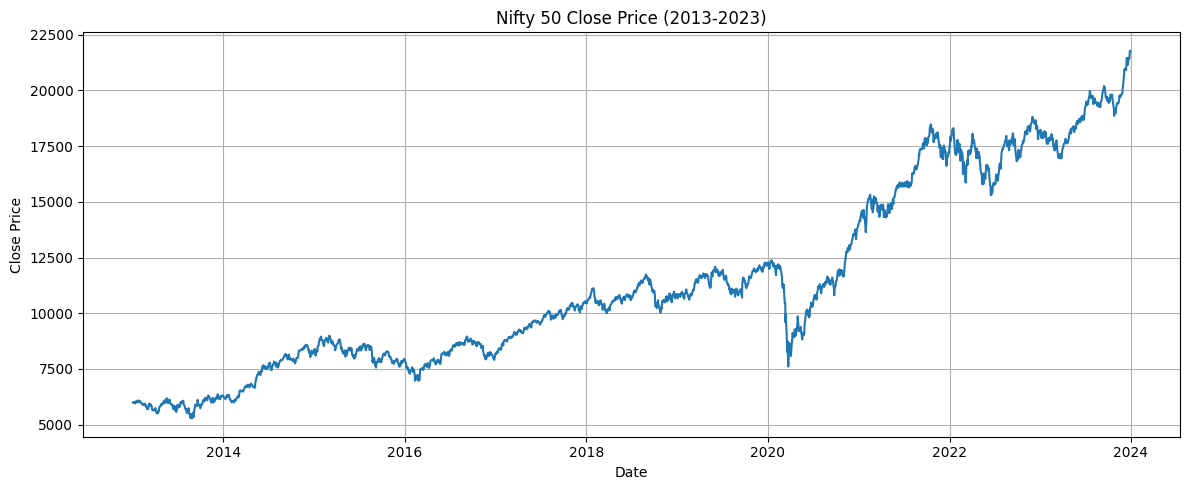

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Close"])
plt.title("Nifty 50 Close Price (2013-2023)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def create_sequences(features, target, window_size):
    X, y, target_indices = [], [], []
    for i in range(window_size, len(features)):
        X.append(features[i - window_size:i])
        y.append(target[i])
        target_indices.append(i)
    return np.array(X), np.array(y), np.array(target_indices)

print("Sequence function created.")

Sequence function created.


In [ ]:
n = len(df)

train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

feature_scaler = MinMaxScaler()
target_scaler  = MinMaxScaler()

features_scaled = feature_scaler.fit_transform(df[FEATURE_COLS])
target_scaled   = target_scaler.fit_transform(df[[TARGET_COL]]).reshape(-1)

X, y, target_indices = create_sequences(features_scaled, target_scaled, WINDOW_SIZE)

train_mask = target_indices < train_end
val_mask   = (target_indices >= train_end) & (target_indices < val_end)
test_mask  = target_indices >= val_end

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

sequence_dates = df.index[target_indices]
val_dates  = sequence_dates[val_mask]
test_dates = sequence_dates[test_mask]

input_shape = (X_train.shape[1], X_train.shape[2])

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}")
print(f"Train dates: {df.index[0].date()} -> {df.index[train_end-1].date()}")
print(f"Val   dates: {val_dates[0].date()} -> {val_dates[-1].date()}")
print(f"Test  dates: {test_dates[0].date()} -> {test_dates[-1].date()}")
print()
print("y_train min/max:", y_train.min(), y_train.max())
print("y_val   min/max:", y_val.min(), y_val.max())
print("y_test  min/max:", y_test.min(), y_test.max())
print()
print("NOTE: y_test range sits ABOVE y_val range (Nifty kept climbing).")
print("This is exactly why tree/kernel meta-learners trained on raw scaled")
print("price levels fail to extrapolate -- handled below via returns-based")
print("meta-learner training (Section 2).")

X_train: (1610, 10, 4)  |  X_val: (405, 10, 4)  |  X_test: (675, 10, 4)
Train dates: 2013-01-02 -> 2019-08-16
Val   dates: 2019-08-19 -> 2021-04-08
Test  dates: 2021-04-09 -> 2023-12-29

y_train min/max: 0.0 0.41249386898927076
y_val   min/max: 0.1409780770924124 0.6080928275878076
y_test  min/max: 0.5463541120224176 0.9999999999999999

NOTE: y_test range sits ABOVE y_val range (Nifty kept climbing).
This is exactly why tree/kernel meta-learners trained on raw scaled
price levels fail to extrapolate -- handled below via returns-based
meta-learner training (Section 2).


In [ ]:
def calculate_metrics(y_true, y_pred, model_name, verbose=True):
    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8)))

    if verbose:
        print(f"\n{model_name}")
        print("-" * 50)
        print(f"MSE  : {mse:.8f}")
        print(f"RMSE : {rmse:.8f}")
        print(f"R2   : {r2:.8f}")
        print(f"MAE  : {mae:.8f}")
        print(f"MAPE : {mape:.8f}")

    return {"Model": model_name, "MSE": mse, "RMSE": rmse, "R2": r2, "MAE": mae, "MAPE": mape}

print("Metric function ready.")

Metric function ready.


# ===========================================================
# SECTION 1 - BASE MODELS  (LSTM, CNN, TCN)
# ===========================================================

In [ ]:
# --- LSTM Base Model --------------------------------------------------------

def build_lstm_model(input_shape):
    model = Sequential(name="LSTM_Base_Model")
    model.add(LSTM(units=64, activation="tanh", input_shape=input_shape))
    model.add(Dropout(0.1))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return model

tf.keras.backend.clear_session()
lstm_model = build_lstm_model(input_shape)
lstm_model.summary()

Model: "LSTM_Base_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_lstm = EarlyStopping(
    monitor="val_loss", patience=15, min_delta=1e-6,
    restore_best_weights=True, start_from_epoch=20
)

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop_lstm], shuffle=False, verbose=1
)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - loss: 0.0236 - val_loss: 0.0520
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0064 - val_loss: 0.0151
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0015 - val_loss: 0.0032
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - val_loss: 9.5535e-04
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.5033e-04 - val_loss: 8.9837e-04
Epoch 10/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.5333e-04 - val_loss: 6.3572e-04
Epoch 11/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.4133e-04 - val_loss: 6.1877e-04
Epoch 12/100
26/26 ━━━━━━━━━━━

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

LSTM Validation
--------------------------------------------------
MSE  : 0.00035594
RMSE : 0.01886650
R2   : 0.96701191
MAE  : 0.01293050
MAPE : 0.03899050

LSTM Test
--------------------------------------------------
MSE  : 0.00049902
RMSE : 0.02233877
R2   : 0.93331691
MAE  : 0.01856887
MAPE : 0.02428142


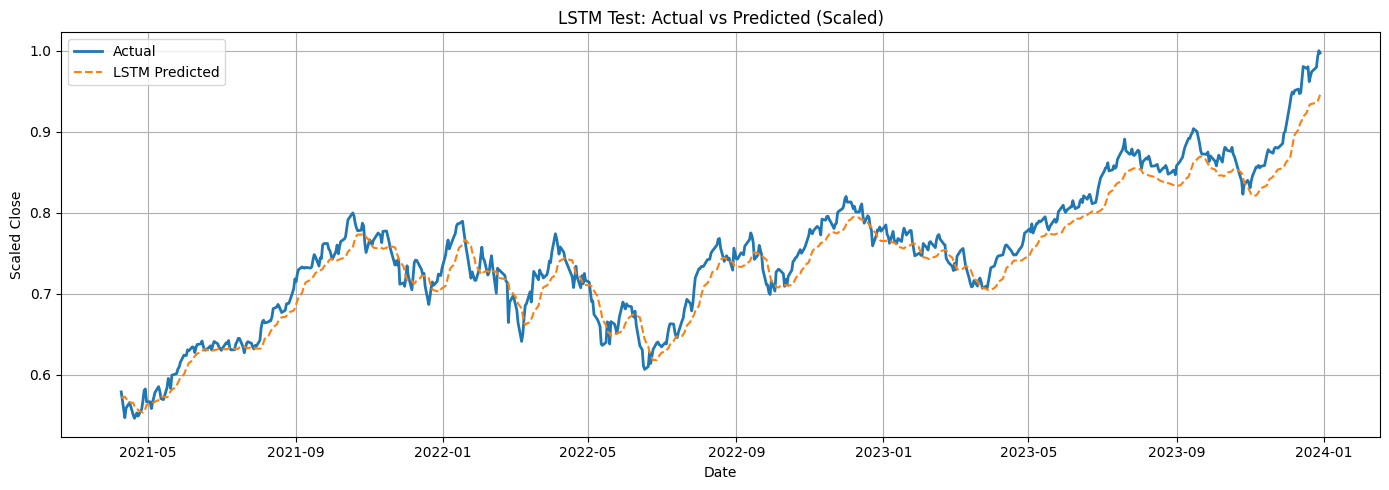

In [ ]:
lstm_val_pred  = lstm_model.predict(X_val).reshape(-1)
lstm_test_pred = lstm_model.predict(X_test).reshape(-1)

lstm_val_metrics  = calculate_metrics(y_val,  lstm_val_pred,  "LSTM Validation")
lstm_test_metrics = calculate_metrics(y_test, lstm_test_pred, "LSTM Test")

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test,          label="Actual",          linewidth=2)
plt.plot(test_dates, lstm_test_pred,  label="LSTM Predicted",  linestyle="--")
plt.title("LSTM Test: Actual vs Predicted (Scaled)")
plt.xlabel("Date"); plt.ylabel("Scaled Close"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

In [ ]:
# --- CNN Base Model -----------------------------------------------------------

def build_cnn_model(input_shape):
    model = Sequential(name="CNN_Base_Model")
    model.add(Conv1D(filters=64, kernel_size=3, activation="relu", input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(64, activation="relu"))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return model

cnn_model = build_cnn_model(input_shape)
cnn_model.summary()

Model: "CNN_Base_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 64)          │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,345 (67.75 KB)

 Trainable params: 17,345 (67.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_cnn = EarlyStopping(
    monitor="val_loss", patience=15, min_delta=1e-6,
    restore_best_weights=True, start_from_epoch=20
)

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop_cnn], shuffle=False, verbose=1
)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0199 - val_loss: 0.0146
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0018 - val_loss: 5.7240e-04
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0021 - val_loss: 7.3727e-04
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0018 - val_loss: 7.7223e-04
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - val_loss: 6.1781e-04
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016 - val_loss: 5.1744e-04
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - val_loss: 6.0368e-04
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - val_loss: 4.7955e-04
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - val_loss: 4.4063e-04
Epoch 10/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 4.2343e-04
Epoch 11/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0013 - val_loss: 4.1279e-04
Epoch 12/100
26/26 ━━━

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

CNN Validation
--------------------------------------------------
MSE  : 0.00035701
RMSE : 0.01889469
R2   : 0.96691326
MAE  : 0.01301726
MAPE : 0.03904082

CNN Test
--------------------------------------------------
MSE  : 0.00031505
RMSE : 0.01774961
R2   : 0.95790072
MAE  : 0.01394443
MAPE : 0.01884190


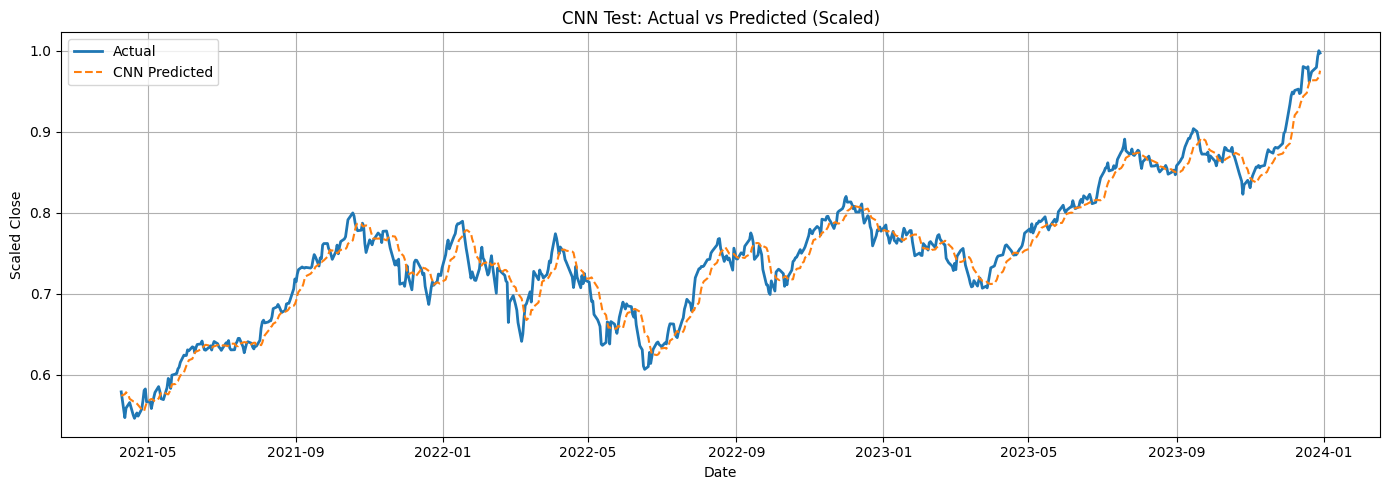

In [ ]:
cnn_val_pred  = cnn_model.predict(X_val).reshape(-1)
cnn_test_pred = cnn_model.predict(X_test).reshape(-1)

cnn_val_metrics  = calculate_metrics(y_val,  cnn_val_pred,  "CNN Validation")
cnn_test_metrics = calculate_metrics(y_test, cnn_test_pred, "CNN Test")

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test,         label="Actual",         linewidth=2)
plt.plot(test_dates, cnn_test_pred,  label="CNN Predicted",  linestyle="--")
plt.title("CNN Test: Actual vs Predicted (Scaled)")
plt.xlabel("Date"); plt.ylabel("Scaled Close"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

In [ ]:
# --- TCN Base Model -----------------------------------------------------------

def build_tcn_model(input_shape):
    model = Sequential(name="TCN_Base_Model")
    model.add(Conv1D(filters=64, kernel_size=3, padding="causal",
                     dilation_rate=1, activation="relu", input_shape=input_shape))
    model.add(Dropout(0.1))
    model.add(Conv1D(filters=64, kernel_size=3, padding="causal",
                     dilation_rate=2, activation="relu"))
    model.add(Dropout(0.1))
    model.add(Flatten())
    model.add(Dense(64, activation="relu"))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return model

np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)
tcn_model = build_tcn_model(input_shape)
tcn_model.summary()

Model: "TCN_Base_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 10, 64)         │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 10, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,273 (212.00 KB)

 Trainable params: 54,273 (212.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_tcn = EarlyStopping(
    monitor="val_loss", patience=10, min_delta=1e-6, restore_best_weights=True
)

history_tcn = tcn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop_tcn], shuffle=False, verbose=1
)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - loss: 0.0028 - val_loss: 0.0012
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.6318e-04 - val_loss: 8.7149e-04
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.1475e-04 - val_loss: 0.0013
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.8344e-04 - val_loss: 9.9957e-04
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.7144e-04 - val_loss: 9.1600e-04
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.7880e-04 - val_loss: 7.7014e-04
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.7524e-04 - val_loss: 7.8304e-04
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.5594e-04 - val_loss: 7.7928e-04
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.4328e-04 - val_loss: 8.4165e-04
Epoch 10/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.3241e-04 - val_loss: 9.0967e-04
Epoch 11/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.4187e-04 - val_

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

TCN Validation
--------------------------------------------------
MSE  : 0.00077014
RMSE : 0.02775146
R2   : 0.92862495
MAE  : 0.01989124
MAPE : 0.05818310

TCN Test
--------------------------------------------------
MSE  : 0.00092006
RMSE : 0.03033241
R2   : 0.87705500
MAE  : 0.02602748
MAPE : 0.03464832


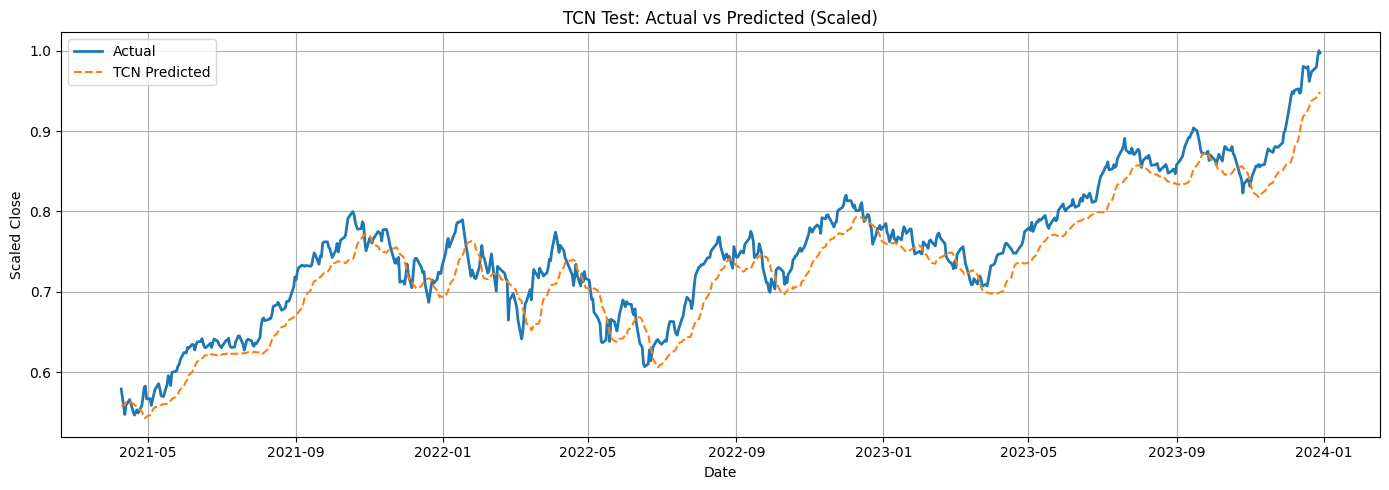

In [ ]:
tcn_val_pred  = tcn_model.predict(X_val).reshape(-1)
tcn_test_pred = tcn_model.predict(X_test).reshape(-1)

tcn_val_metrics  = calculate_metrics(y_val,  tcn_val_pred,  "TCN Validation")
tcn_test_metrics = calculate_metrics(y_test, tcn_test_pred, "TCN Test")

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test,         label="Actual",         linewidth=2)
plt.plot(test_dates, tcn_test_pred,  label="TCN Predicted",  linestyle="--")
plt.title("TCN Test: Actual vs Predicted (Scaled)")
plt.xlabel("Date"); plt.ylabel("Scaled Close"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# ===========================================================
# SECTION 2 - STACKED ENSEMBLE  (Linear vs Non-Linear Meta-Learners)
#
# WHY THIS SECTION IS DIFFERENT FROM A NAIVE IMPLEMENTATION:
#
# Nifty 50 trended upward across 2013-2023, so the scaled "Close" level
# seen in the test period (~0.55-1.00) sits entirely ABOVE the range the
# meta-learner would see if trained on raw validation-period levels
# (~0.14-0.61). Tree-based models (XGBoost, Random Forest) and kernel
# models (SVR) cannot extrapolate past the value range they were trained
# on -- a tree's prediction is just the mean of a leaf's training samples,
# and an RBF kernel's influence decays with distance from training points.
# Trained on raw levels, every non-linear meta-learner collapses toward
# the validation-period price range when it sees test-period inputs,
# producing the catastrophic negative R2 you'd get from a naive setup.
#
# FIX: train the meta-learner on the FIRST DIFFERENCE (change) between
# the two base learners' predictions and the previous actual value,
# rather than on raw price levels. Differences/returns are approximately
# stationary -- their distribution doesn't drift the way raw price levels
# do -- so the meta-learner is no longer asked to extrapolate into unseen
# territory. The final forecast is then reconstructed by adding the
# predicted change back onto the last known actual price (a standard
# "differencing" trick in time-series forecasting).
#
# Ensemble 1 base learners: LSTM + CNN
# Ensemble 2 base learners: LSTM + TCN
# ===========================================================

In [ ]:
# --- Build meta-learner features using DIFFERENCES, not raw levels ---------
#
# For each base model, convert its prediction into a "predicted change"
# relative to the previous actual value:
#     delta_pred[t] = base_pred[t] - y[t-1]
# The meta-learner learns to combine these deltas into a final predicted
# delta, which is then added back onto y[t-1] to reconstruct the price.
#
# y_val[t-1] / y_test[t-1] are simply the previous actual scaled values
# (available at prediction time in a real walk-forward forecasting setup).

def to_deltas(base_pred, y_true):
    """Convert level predictions into deltas relative to the previous actual value."""
    prev_actual = np.concatenate([[y_true[0]], y_true[:-1]])  # y[t-1], with y[0] used as its own anchor
    return base_pred - prev_actual, prev_actual

# Validation set deltas (used to TRAIN the meta-learner)
lstm_val_delta, val_prev = to_deltas(lstm_val_pred, y_val)
cnn_val_delta,  _        = to_deltas(cnn_val_pred,  y_val)
tcn_val_delta,  _        = to_deltas(tcn_val_pred,  y_val)
y_val_delta               = y_val - val_prev   # true delta to predict during training

# Test set deltas (used to EVALUATE the meta-learner)
lstm_test_delta, test_prev = to_deltas(lstm_test_pred, y_test)
cnn_test_delta,  _         = to_deltas(cnn_test_pred,  y_test)
tcn_test_delta,  _         = to_deltas(tcn_test_pred,  y_test)

# Ensemble 1: LSTM + CNN  (delta-space features)
meta_train_e1 = np.column_stack([lstm_val_delta,  cnn_val_delta])
meta_test_e1  = np.column_stack([lstm_test_delta, cnn_test_delta])

# Ensemble 2: LSTM + TCN  (delta-space features)
meta_train_e2 = np.column_stack([lstm_val_delta,  tcn_val_delta])
meta_test_e2  = np.column_stack([lstm_test_delta, tcn_test_delta])

print("Meta-train shape (E1):", meta_train_e1.shape)
print("Meta-test  shape (E1):", meta_test_e1.shape)
print("Meta-train shape (E2):", meta_train_e2.shape)
print("Meta-test  shape (E2):", meta_test_e2.shape)

print("\nDelta ranges (should overlap between val and test, unlike raw levels):")
print(f"  val  delta range:  [{y_val_delta.min():.4f}, {y_val_delta.max():.4f}]")
print(f"  test delta range:  [{(y_test - test_prev).min():.4f}, {(y_test - test_prev).max():.4f}]")

Meta-train shape (E1): (405, 2)
Meta-test  shape (E1): (675, 2)
Meta-train shape (E2): (405, 2)
Meta-test  shape (E2): (675, 2)

Delta ranges (should overlap between val and test, unlike raw levels):
  val  delta range:  [-0.0688, 0.0429]
  test delta range:  [-0.0494, 0.0309]


In [ ]:
# --- Define all meta-learners -----------------------------------------------
#
# [A] LinearRegression  - paper baseline (no hyperparameters needed)
# [B] XGBoost           - non-linear gradient boosting (shallow, regularized)
# [C] Random Forest     - non-linear bagging ensemble (shallow)
# [D] SVR                - non-linear kernel method
# [E] MLP                - small neural network meta-learner
#
# Models are kept shallow/regularized since the meta-learner only has
# 2 input features (the two base learners' deltas) and ~405 training rows --
# a small, simple problem where deep/complex models would just overfit noise.

def make_meta_learners():
    return {
        "Linear":       LinearRegression(),
        "XGBoost":      XGBRegressor(
                            n_estimators=100,
                            max_depth=2,
                            learning_rate=0.05,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            reg_lambda=1.0,
                            random_state=SEED,
                            verbosity=0
                        ),
        "RandomForest": RandomForestRegressor(
                            n_estimators=100,
                            max_depth=3,
                            min_samples_leaf=5,
                            random_state=SEED,
                            n_jobs=-1
                        ),
        "SVR":          SVR(kernel="rbf", C=1.0, epsilon=0.001, gamma="scale"),
        "MLP":          MLPRegressor(
                            hidden_layer_sizes=(16,),
                            activation="relu",
                            alpha=0.01,
                            max_iter=2000,
                            random_state=SEED
                        ),
    }

meta_learners = make_meta_learners()
print("Meta-learners defined:", list(meta_learners.keys()))

Meta-learners defined: ['Linear', 'XGBoost', 'RandomForest', 'SVR', 'MLP']


In [ ]:
# --- Train & evaluate every (Ensemble, Meta-Learner) combination -----------
#
# The meta-learner is trained in DELTA space (predicting the change),
# then its predicted deltas are added back onto the previous actual value
# to reconstruct the final price-level prediction, which is what we
# actually evaluate against y_test (matching how the original paper
# reports metrics on price levels).

all_results = []

for ensemble_name, (meta_train, meta_test) in [
    ("E1 (LSTM+CNN)", (meta_train_e1, meta_test_e1)),
    ("E2 (LSTM+TCN)", (meta_train_e2, meta_test_e2)),
]:
    print(f"\n{'='*60}")
    print(f"  {ensemble_name}")
    print(f"{'='*60}")

    fresh_learners = make_meta_learners()

    for learner_name, learner in fresh_learners.items():
        # Train meta-learner on DELTA space
        learner.fit(meta_train, y_val_delta)

        # Predict delta on test set, then reconstruct price level
        pred_delta = learner.predict(meta_test)
        ensemble_pred = test_prev + pred_delta   # reconstruct level prediction

        tag = f"{ensemble_name} | {learner_name}"
        m   = calculate_metrics(y_test, ensemble_pred, tag)
        m["Ensemble"]     = ensemble_name
        m["Meta-Learner"] = learner_name
        all_results.append(m)

        # Stash E2 predictions for later plotting
        if ensemble_name == "E2 (LSTM+TCN)":
            globals()[f"pred_{learner_name.lower()}"] = ensemble_pred

print("\nAll combinations evaluated.")


  E1 (LSTM+CNN)

E1 (LSTM+CNN) | Linear
--------------------------------------------------
MSE  : 0.00008369
RMSE : 0.00914801
R2   : 0.98881719
MAE  : 0.00690721
MAPE : 0.00945431

E1 (LSTM+CNN) | XGBoost
--------------------------------------------------
MSE  : 0.00008666
RMSE : 0.00930888
R2   : 0.98842045
MAE  : 0.00701903
MAPE : 0.00961911

E1 (LSTM+CNN) | RandomForest
--------------------------------------------------
MSE  : 0.00008438
RMSE : 0.00918585
R2   : 0.98872450
MAE  : 0.00692587
MAPE : 0.00948257

E1 (LSTM+CNN) | SVR
--------------------------------------------------
MSE  : 0.00022548
RMSE : 0.01501593
R2   : 0.96986984
MAE  : 0.01110562
MAPE : 0.01456791

E1 (LSTM+CNN) | MLP
--------------------------------------------------
MSE  : 0.00010387
RMSE : 0.01019172
R2   : 0.98611993
MAE  : 0.00781884
MAPE : 0.01069047

  E2 (LSTM+TCN)

E2 (LSTM+TCN) | Linear
--------------------------------------------------
MSE  : 0.00008577
RMSE : 0.00926144
R2   : 0.98853817
MAE  : 0.00

In [ ]:
# --- Summary comparison table ------------------------------------------------

results_df = pd.DataFrame(all_results)[
    ["Ensemble", "Meta-Learner", "MSE", "RMSE", "R2", "MAE", "MAPE"]
].sort_values(["Ensemble", "MSE"])

pd.set_option("display.float_format", "{:.8f}".format)
print("\n" + "="*80)
print("  FULL RESULTS: Base Models + All Ensemble / Meta-Learner Combinations")
print("="*80)

base_rows = []
for m in [lstm_test_metrics, cnn_test_metrics, tcn_test_metrics]:
    row = m.copy()
    row["Ensemble"]     = "Individual"
    row["Meta-Learner"] = "-"
    base_rows.append(row)

base_df = pd.DataFrame(base_rows)[["Ensemble","Meta-Learner","MSE","RMSE","R2","MAE","MAPE"]]

full_df = pd.concat([base_df, results_df], ignore_index=True)
display(full_df)


  FULL RESULTS: Base Models + All Ensemble / Meta-Learner Combinations


,Ensemble,Meta-Learner,MSE,RMSE,R2,MAE,MAPE
0,Individual,-,0.00049902,0.02233877,0.93331691,0.01856887,0.02428142
1,Individual,-,0.00031505,0.01774961,0.95790072,0.01394443,0.01884190
2,Individual,-,0.00092006,0.03033241,0.87705500,0.02602748,0.03464832
3,E1 (LSTM+CNN),Linear,0.00008369,0.00914801,0.98881719,0.00690721,0.00945431
4,E1 (LSTM+CNN),RandomForest,0.00008438,0.00918585,0.98872450,0.00692587,0.00948257
5,E1 (LSTM+CNN),XGBoost,0.00008666,0.00930888,0.98842045,0.00701903,0.00961911
6,E1 (LSTM+CNN),MLP,0.00010387,0.01019172,0.98611993,0.00781884,0.01069047
7,E1 (LSTM+CNN),SVR,0.00022548,0.01501593,0.96986984,0.01110562,0.01456791
8,E2 (LSTM+TCN),RandomForest,0.00008295,0.00910771,0.98891551,0.00689176,0.00941953
9,E2 (LSTM+TCN),Linear,0.00008577,0.00926144,0.98853817,0.00708487,0.00963413


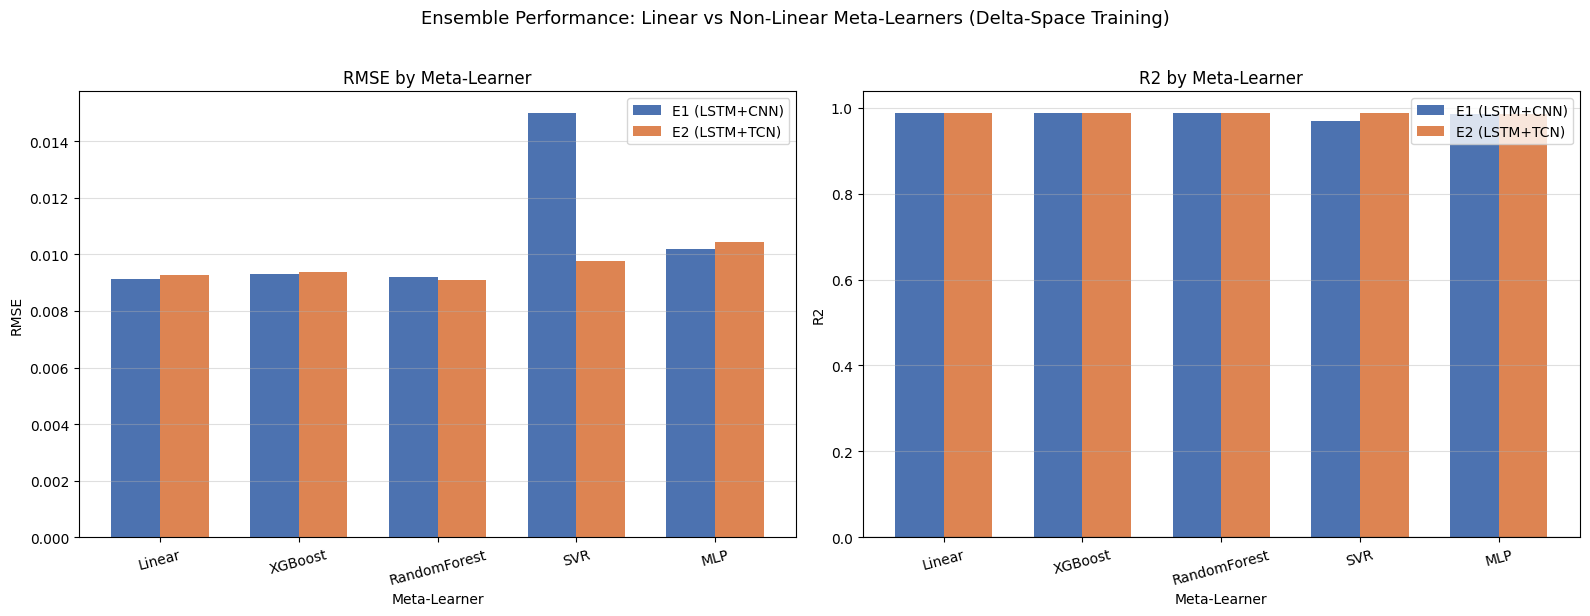

In [ ]:
# --- Bar chart: RMSE / R2 by meta-learner for both ensembles ----------------

e1_df = results_df[results_df["Ensemble"] == "E1 (LSTM+CNN)"].set_index("Meta-Learner")
e2_df = results_df[results_df["Ensemble"] == "E2 (LSTM+TCN)"].set_index("Meta-Learner")

learner_names = list(meta_learners.keys())
x = np.arange(len(learner_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric in zip(axes, ["RMSE", "R2"]):
    vals_e1 = [e1_df.loc[n, metric] for n in learner_names]
    vals_e2 = [e2_df.loc[n, metric] for n in learner_names]

    ax.bar(x - width/2, vals_e1, width, label="E1 (LSTM+CNN)", color="#4C72B0")
    ax.bar(x + width/2, vals_e2, width, label="E2 (LSTM+TCN)", color="#DD8452")

    ax.set_xlabel("Meta-Learner")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} by Meta-Learner")
    ax.set_xticks(x)
    ax.set_xticklabels(learner_names, rotation=15)
    ax.legend()
    ax.grid(axis="y", alpha=0.4)
    if metric == "R2":
        ax.axhline(0, color="black", linewidth=0.8)

plt.suptitle("Ensemble Performance: Linear vs Non-Linear Meta-Learners (Delta-Space Training)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [1]:
e1_df = results_df[results_df["Ensemble"] == "E1 (LSTM+CNN)"].set_index("Meta-Learner")
e2_df = results_df[results_df["Ensemble"] == "E2 (LSTM+TCN)"].set_index("Meta-Learner")

learner_names = list(meta_learners.keys())
x = np.arange(len(learner_names))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))

vals_e1 = [e1_df.loc[n, "R2"] for n in learner_names]
vals_e2 = [e2_df.loc[n, "R2"] for n in learner_names]

ax.bar(x - width/2, vals_e1, width, label="E1 (LSTM+CNN)", color="#4C72B0")
ax.bar(x + width/2, vals_e2, width, label="E2 (LSTM+TCN)", color="#DD8452")

ax.set_xlabel("Meta-Learner")
ax.set_ylabel("R2")
ax.set_title("R2 by Meta-Learner (Ensembles E1 & E2)")
ax.set_xticks(x)
ax.set_xticklabels(learner_names, rotation=45, ha='right')
ax.set_ylim(0.96, 1.00) # Set y-axis limit as requested
ax.legend()
ax.grid(axis="y", alpha=0.4)

plt.suptitle("Ensemble Performance: R2 Values (Delta-Space Training)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

NameError: name 'results_df' is not defined

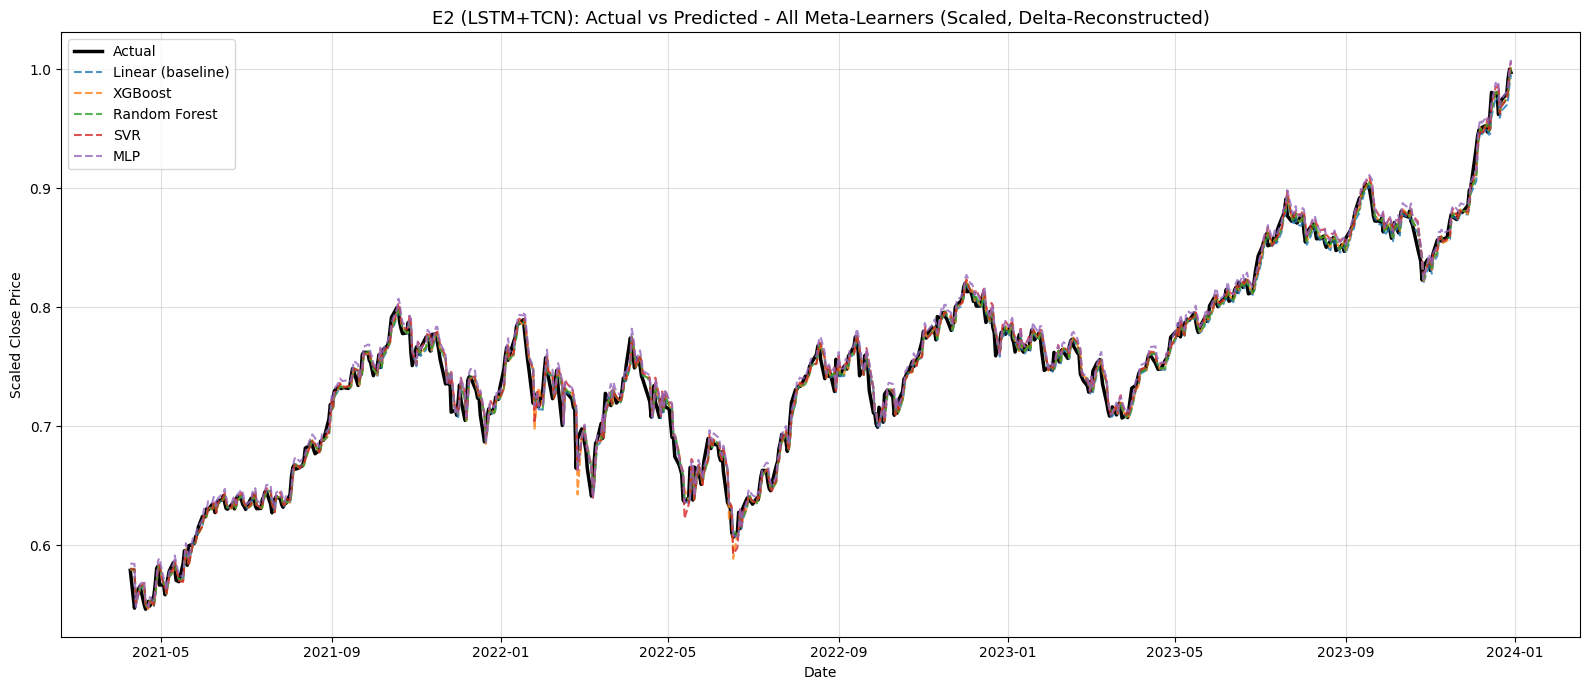

In [ ]:
# --- Prediction plot: all meta-learners on E2 (scaled) ----------------------

plt.figure(figsize=(16, 7))
plt.plot(test_dates, y_test,        label="Actual",            linewidth=2.5, color="black")
plt.plot(test_dates, pred_linear,   label="Linear (baseline)",  linestyle="--", alpha=0.8)
plt.plot(test_dates, pred_xgboost,  label="XGBoost",            linestyle="--", alpha=0.8)
plt.plot(test_dates, pred_randomforest, label="Random Forest",  linestyle="--", alpha=0.8)
plt.plot(test_dates, pred_svr,      label="SVR",                linestyle="--", alpha=0.8)
plt.plot(test_dates, pred_mlp,      label="MLP",                linestyle="--", alpha=0.8)

plt.title("E2 (LSTM+TCN): Actual vs Predicted - All Meta-Learners (Scaled, Delta-Reconstructed)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Scaled Close Price")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

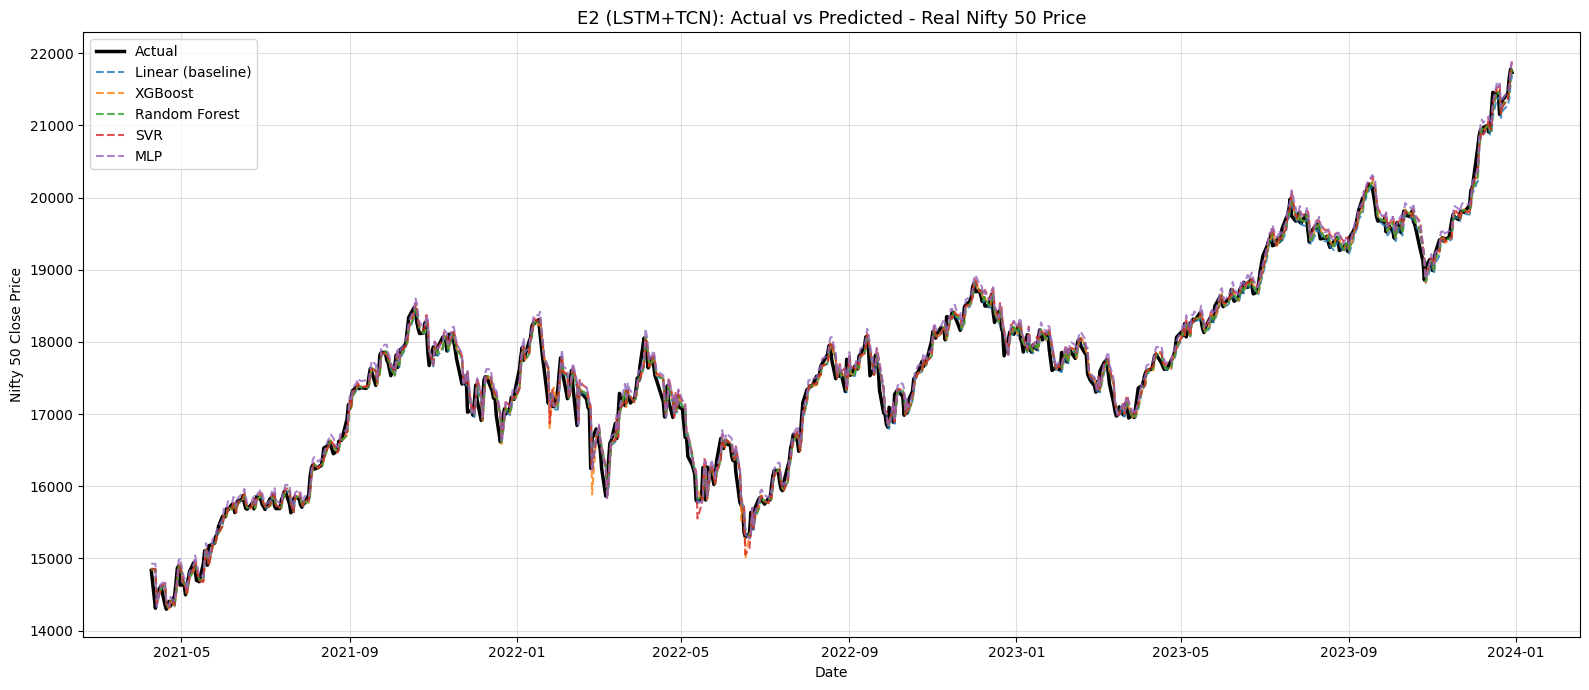

In [ ]:
# --- Convert predictions back to real Nifty price ---------------------------

def to_price(arr):
    return target_scaler.inverse_transform(arr.reshape(-1,1)).reshape(-1)

y_test_price       = to_price(y_test)
price_linear        = to_price(pred_linear)
price_xgb           = to_price(pred_xgboost)
price_rf            = to_price(pred_randomforest)
price_svr           = to_price(pred_svr)
price_mlp           = to_price(pred_mlp)

plt.figure(figsize=(16, 7))
plt.plot(test_dates, y_test_price,  label="Actual",            linewidth=2.5, color="black")
plt.plot(test_dates, price_linear,  label="Linear (baseline)", linestyle="--", alpha=0.8)
plt.plot(test_dates, price_xgb,     label="XGBoost",           linestyle="--", alpha=0.8)
plt.plot(test_dates, price_rf,      label="Random Forest",     linestyle="--", alpha=0.8)
plt.plot(test_dates, price_svr,     label="SVR",               linestyle="--", alpha=0.8)
plt.plot(test_dates, price_mlp,     label="MLP",               linestyle="--", alpha=0.8)

plt.title("E2 (LSTM+TCN): Actual vs Predicted - Real Nifty 50 Price", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Nifty 50 Close Price")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# ===========================================================
# SECTION 3 - 5-FOLD CROSS-VALIDATION (robustness check)
#
# Same delta-space training/reconstruction approach is used inside each fold.
# ===========================================================

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=False)

cv_results = {name: {"MSE":[], "RMSE":[], "R2":[], "MAE":[], "MAPE":[]}
              for name in meta_learners}

# Combine val+test base-model deltas and actual previous-values/targets
# so CV folds are drawn from the full delta-space dataset (~1080 rows).
meta_full_delta   = np.vstack([meta_train_e2, meta_test_e2])             # (1080, 2) deltas
y_full_delta      = np.concatenate([y_val_delta, y_test - test_prev])     # (1080,)   true deltas
prev_full         = np.concatenate([val_prev, test_prev])                 # (1080,)   previous actual values
y_full_level      = np.concatenate([y_val, y_test])                       # (1080,)   true levels

print("Running 5-Fold CV on E2 (LSTM+TCN) meta-learner predictions (delta-space)...\n")

fold_num = 1
for train_idx, test_idx in kf.split(meta_full_delta):
    print(f"  Fold {fold_num}/5 ...", end=" ")

    Xm_tr, Xm_te   = meta_full_delta[train_idx], meta_full_delta[test_idx]
    ydelta_tr      = y_full_delta[train_idx]
    prev_te        = prev_full[test_idx]
    ylevel_te      = y_full_level[test_idx]

    fold_learners = make_meta_learners()

    for learner_name, learner in fold_learners.items():
        learner.fit(Xm_tr, ydelta_tr)
        pred_delta = learner.predict(Xm_te)
        pred_level = prev_te + pred_delta   # reconstruct price level

        m = calculate_metrics(ylevel_te, pred_level, "", verbose=False)
        for metric in ["MSE","RMSE","R2","MAE","MAPE"]:
            cv_results[learner_name][metric].append(m[metric])

    print("done")
    fold_num += 1

print("\nCross-validation complete.")

Running 5-Fold CV on E2 (LSTM+TCN) meta-learner predictions (delta-space)...

  Fold 1/5 ... done
  Fold 2/5 ... done
  Fold 3/5 ... done
  Fold 4/5 ... done
  Fold 5/5 ... done

Cross-validation complete.


In [ ]:
# --- CV summary table ---------------------------------------------------------

cv_rows = []
for learner_name, scores in cv_results.items():
    row = {"Meta-Learner": learner_name}
    for metric, vals in scores.items():
        row[f"{metric} (mean)"] = np.mean(vals)
        row[f"{metric} (std)"]  = np.std(vals)
    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).set_index("Meta-Learner")
display(cv_df[["MSE (mean)","RMSE (mean)","R2 (mean)","MAE (mean)","MAPE (mean)",
               "RMSE (std)","R2 (std)"]])

,MSE (mean),RMSE (mean),R2 (mean),MAE (mean),MAPE (mean),RMSE (std),R2 (std)
Meta-Learner,,,,,,,
Linear,0.00009613,0.00969368,0.97638549,0.00710250,0.01418474,0.00146917,0.01113749
XGBoost,0.00010123,0.00988979,0.97512581,0.00714125,0.01435165,0.00185087,0.01242444
RandomForest,0.00009716,0.00970053,0.97621311,0.00706184,0.01418779,0.00175003,0.01157570
SVR,0.00009398,0.00962297,0.97645588,0.00714339,0.01397260,0.00117225,0.01141676
MLP,0.00010798,0.01020254,0.97385134,0.00745216,0.01526283,0.00197270,0.01272824


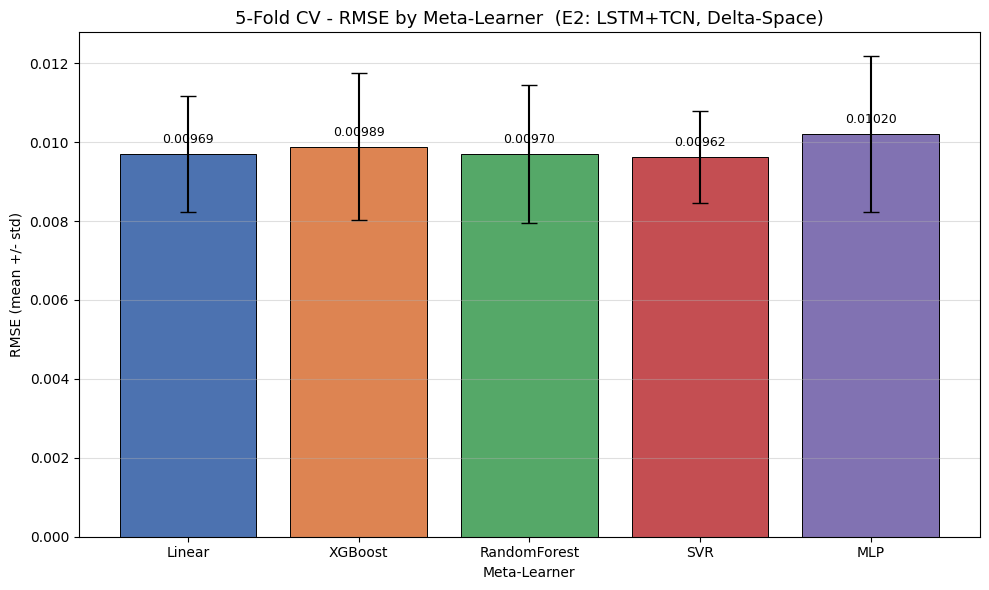

In [ ]:
# --- CV RMSE bar chart with std error bars ------------------------------------

learner_names = list(cv_results.keys())
means = [np.mean(cv_results[n]["RMSE"]) for n in learner_names]
stds  = [np.std(cv_results[n]["RMSE"])  for n in learner_names]

colors = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]

plt.figure(figsize=(10, 6))
bars = plt.bar(learner_names, means, yerr=stds, capsize=6,
               color=colors, edgecolor="black", linewidth=0.7)

for bar, val in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f"{val:.5f}", ha="center", va="bottom", fontsize=9)

plt.title("5-Fold CV - RMSE by Meta-Learner  (E2: LSTM+TCN, Delta-Space)", fontsize=13)
plt.xlabel("Meta-Learner")
plt.ylabel("RMSE (mean +/- std)")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# --- Final summary print -------------------------------------------------------

print("\n" + "="*70)
print("  FINAL SUMMARY - Test Set Performance (E2: LSTM+TCN)")
print("="*70)
print(f"{'Meta-Learner':<16} {'MSE':>12} {'RMSE':>10} {'R2':>10} {'MAE':>10} {'MAPE':>10}")
print("-"*70)

for r in all_results:
    if "LSTM+TCN" in r["Ensemble"]:
        print(f"{r['Meta-Learner']:<16} {r['MSE']:>12.6e} {r['RMSE']:>10.6f} "
              f"{r['R2']:>10.6f} {r['MAE']:>10.6f} {r['MAPE']:>10.6f}")

print("="*70)
print("\nBaseline individual models (test set):")
for m in [lstm_test_metrics, cnn_test_metrics, tcn_test_metrics]:
    print(f"  {m['Model']:<22} MSE={m['MSE']:.6e}  RMSE={m['RMSE']:.6f}  R2={m['R2']:.6f}")

print("\n" + "="*70)
print("  5-FOLD CV SUMMARY (E2: LSTM+TCN)")
print("="*70)
display(cv_df[["MSE (mean)","RMSE (mean)","R2 (mean)","MAE (mean)","MAPE (mean)"]])


  FINAL SUMMARY - Test Set Performance (E2: LSTM+TCN)
Meta-Learner              MSE       RMSE         R2        MAE       MAPE
----------------------------------------------------------------------
Linear           8.577426e-05   0.009261   0.988538   0.007085   0.009634
XGBoost          8.778728e-05   0.009369   0.988269   0.007049   0.009655
RandomForest     8.295045e-05   0.009108   0.988916   0.006892   0.009420
SVR              9.554797e-05   0.009775   0.987232   0.007378   0.010077
MLP              1.088959e-04   0.010435   0.985448   0.008079   0.011030

Baseline individual models (test set):
  LSTM Test              MSE=4.990209e-04  RMSE=0.022339  R2=0.933317
  CNN Test               MSE=3.150487e-04  RMSE=0.017750  R2=0.957901
  TCN Test               MSE=9.200551e-04  RMSE=0.030332  R2=0.877055

  5-FOLD CV SUMMARY (E2: LSTM+TCN)


,MSE (mean),RMSE (mean),R2 (mean),MAE (mean),MAPE (mean)
Meta-Learner,,,,,
Linear,0.00009613,0.00969368,0.97638549,0.00710250,0.01418474
XGBoost,0.00010123,0.00988979,0.97512581,0.00714125,0.01435165
RandomForest,0.00009716,0.00970053,0.97621311,0.00706184,0.01418779
SVR,0.00009398,0.00962297,0.97645588,0.00714339,0.01397260
MLP,0.00010798,0.01020254,0.97385134,0.00745216,0.01526283


### Re-running 5-Fold Cross-Validation with New Meta-Learners

In [ ]:
fresh_learners_cv = make_meta_learners()

cv_results_updated = {name: {"MSE":[], "RMSE":[], "R2":[], "MAE":[], "MAPE":[]} for name in fresh_learners_cv}

print("Running 5-Fold CV on E2 (LSTM+TCN) meta-learner predictions (delta-space) with UPDATED meta-learners...\n")

fold_num = 1
for train_idx, test_idx in kf.split(meta_full_delta):
    print(f"  Fold {fold_num}/5 ...", end=" ")

    Xm_tr, Xm_te   = meta_full_delta[train_idx], meta_full_delta[test_idx]
    ydelta_tr      = y_full_delta[train_idx]
    prev_te        = prev_full[test_idx]
    ylevel_te      = y_full_level[test_idx]

    for learner_name, learner in fresh_learners_cv.items():
        learner.fit(Xm_tr, ydelta_tr)
        pred_delta = learner.predict(Xm_te)
        pred_level = prev_te + pred_delta   # reconstruct price level

        m = calculate_metrics(ylevel_te, pred_level, "", verbose=False)
        for metric in ["MSE","RMSE","R2","MAE","MAPE"]:
            cv_results_updated[learner_name][metric].append(m[metric])

    print("done")
    fold_num += 1

print("\nCross-validation with updated meta-learners complete.")

Running 5-Fold CV on E2 (LSTM+TCN) meta-learner predictions (delta-space) with UPDATED meta-learners...

  Fold 1/5 ... done
  Fold 2/5 ... done
  Fold 3/5 ... done
  Fold 4/5 ... done
  Fold 5/5 ... done

Cross-validation with updated meta-learners complete.


### Updated CV Summary Table

In [ ]:
cv_rows_updated = []
for learner_name, scores in cv_results_updated.items():
    row = {"Meta-Learner": learner_name}
    for metric, vals in scores.items():
        row[f"{metric} (mean)"] = np.mean(vals)
        row[f"{metric} (std)"]  = np.std(vals)
    cv_rows_updated.append(row)

cv_df_updated = pd.DataFrame(cv_rows_updated).set_index("Meta-Learner")
display(cv_df_updated[["MSE (mean)","RMSE (mean)","R2 (mean)","MAE (mean)","MAPE (mean)",
                       "RMSE (std)","R2 (std)"]])

,MSE (mean),RMSE (mean),R2 (mean),MAE (mean),MAPE (mean),RMSE (std),R2 (std)
Meta-Learner,,,,,,,
Linear,0.00009613,0.00969368,0.97638549,0.00710250,0.01418474,0.00146917,0.01113749
XGBoost,0.00010123,0.00988979,0.97512581,0.00714125,0.01435165,0.00185087,0.01242444
RandomForest,0.00009716,0.00970053,0.97621311,0.00706184,0.01418779,0.00175003,0.01157570
SVR,0.00009398,0.00962297,0.97645588,0.00714339,0.01397260,0.00117225,0.01141676
MLP,0.00010798,0.01020254,0.97385134,0.00745216,0.01526283,0.00197270,0.01272824


### Updated CV RMSE Bar Chart

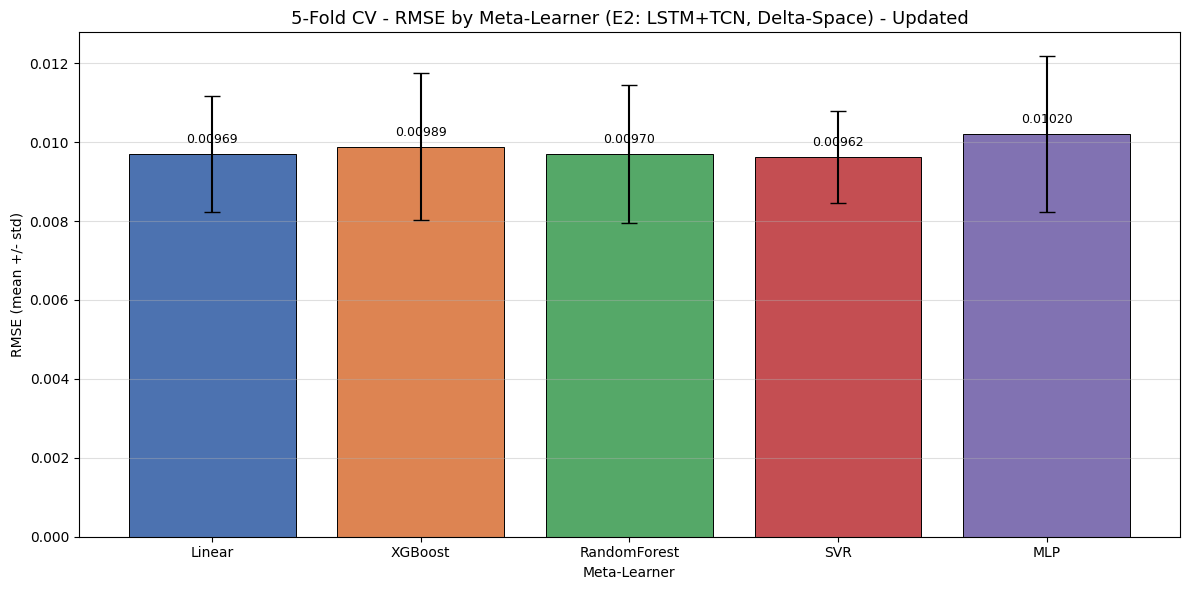

In [ ]:
learner_names_updated = list(cv_results_updated.keys())
means_updated = [np.mean(cv_results_updated[n]["RMSE"]) for n in learner_names_updated]
stds_updated  = [np.std(cv_results_updated[n]["RMSE"])  for n in learner_names_updated]

# Extend colors if needed for new learners
if len(colors) < len(learner_names_updated):
    # Using a cyclical color map to avoid running out of colors
    cmap = plt.cm.get_cmap('viridis', len(learner_names_updated))
    extended_colors = [cmap(i) for i in range(len(learner_names_updated))]
else:
    extended_colors = colors[:len(learner_names_updated)]

plt.figure(figsize=(12, 6))
bars = plt.bar(learner_names_updated, means_updated, yerr=stds_updated, capsize=6,
               color=extended_colors, edgecolor="black", linewidth=0.7)

for bar, val in zip(bars, means_updated):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f"{val:.5f}", ha="center", va="bottom", fontsize=9)

plt.title("5-Fold CV - RMSE by Meta-Learner (E2: LSTM+TCN, Delta-Space) - Updated", fontsize=13)
plt.xlabel("Meta-Learner")
plt.ylabel("RMSE (mean +/- std)")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# --- 5-FOLD CV FOR ENSEMBLE 1 (LSTM + CNN) ---

print("Running 5-Fold CV on E1 (LSTM+CNN) meta-learner predictions (delta-space)...\n")

# Use the E1 variables this time
meta_full_delta_e1 = np.vstack([meta_train_e1, meta_test_e1])            # (1080, 2) deltas for E1
# y_full_delta, prev_full, and y_full_level remain exactly the same as before

cv_results_e1 = {name: {"MSE":[], "RMSE":[], "R2":[], "MAE":[], "MAPE":[]}
               for name in meta_learners}

fold_num = 1
for train_idx, test_idx in kf.split(meta_full_delta_e1):
    print(f"  Fold {fold_num}/5 ...", end=" ")

    Xm_tr, Xm_te   = meta_full_delta_e1[train_idx], meta_full_delta_e1[test_idx]
    ydelta_tr      = y_full_delta[train_idx]
    prev_te        = prev_full[test_idx]
    ylevel_te      = y_full_level[test_idx]

    fold_learners = make_meta_learners()

    for learner_name, learner in fold_learners.items():
        learner.fit(Xm_tr, ydelta_tr)
        pred_delta = learner.predict(Xm_te)
        pred_level = prev_te + pred_delta   # reconstruct price level

        m = calculate_metrics(ylevel_te, pred_level, "", verbose=False)
        for metric in ["MSE","RMSE","R2","MAE","MAPE"]:
            cv_results_e1[learner_name][metric].append(m[metric])

    print("done")
    fold_num += 1

print("\nCross-validation for E1 complete.")

# --- Summary Table for E1 ---
cv_rows_e1 = []
for learner_name, scores in cv_results_e1.items():
    row = {"Meta-Learner": learner_name}
    for metric, vals in scores.items():
        row[f"{metric} (mean)"] = np.mean(vals)
        row[f"{metric} (std)"]  = np.std(vals)
    cv_rows_e1.append(row)

cv_df_e1 = pd.DataFrame(cv_rows_e1).set_index("Meta-Learner")
display(cv_df_e1[["MSE (mean)","RMSE (mean)","R2 (mean)","MAE (mean)","MAPE (mean)"]])

Running 5-Fold CV on E1 (LSTM+CNN) meta-learner predictions (delta-space)...

  Fold 1/5 ... done
  Fold 2/5 ... done
  Fold 3/5 ... done
  Fold 4/5 ... done
  Fold 5/5 ... done

Cross-validation for E1 complete.


,MSE (mean),RMSE (mean),R2 (mean),MAE (mean),MAPE (mean)
Meta-Learner,,,,,
Linear,0.00009537,0.00963558,0.97653803,0.00705205,0.01414216
XGBoost,0.00010099,0.00987168,0.97535861,0.00712374,0.01433370
RandomForest,0.00009865,0.00977337,0.97592261,0.00709249,0.01426889
SVR,0.00013426,0.01145296,0.96847234,0.00803454,0.01588035
MLP,0.00010100,0.00989152,0.97535150,0.00726088,0.01471145


## Adding New Meta-Learner Models

As requested, we will now add `HuberRegressor`, `Ridge`, and `Lasso` to the set of meta-learner models and re-evaluate their performance.

In [ ]:
from sklearn.linear_model import HuberRegressor, Ridge, Lasso
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, StackingRegressor

def make_meta_learners():
    # Define base estimators for StackingRegressor
    base_estimators = [
        ('linear', LinearRegression()),
        ('xgb', XGBRegressor(
            n_estimators=50, max_depth=1, learning_rate=0.05, random_state=SEED, verbosity=0)),
        ('rf', RandomForestRegressor(
            n_estimators=50, max_depth=2, min_samples_leaf=5, random_state=SEED, n_jobs=-1))
    ]

    return {
        "Linear":       LinearRegression(),
        "XGBoost":      XGBRegressor(
                            n_estimators=100,
                            max_depth=2,
                            learning_rate=0.05,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            reg_lambda=1.0,
                            random_state=SEED,
                            verbosity=0
                        ),
        "RandomForest": RandomForestRegressor(
                            n_estimators=100,
                            max_depth=3,
                            min_samples_leaf=5,
                            random_state=SEED,
                            n_jobs=-1
                        ),
        "SVR":          SVR(kernel="rbf", C=1.0, epsilon=0.001, gamma="scale"),
        "MLP":          MLPRegressor(
                            hidden_layer_sizes=(16,),
                            activation="relu",
                            alpha=0.01,
                            max_iter=2000,
                            random_state=SEED
                        ),
        "Huber":        HuberRegressor(epsilon=1.35, max_iter=500, alpha=0.0001),
        "Ridge":        Ridge(alpha=1.0, random_state=SEED),
        "Lasso":        Lasso(alpha=0.0001, random_state=SEED, max_iter=2000),
        "LightGBM":     LGBMRegressor(random_state=SEED, n_estimators=100, num_leaves=10, learning_rate=0.05),
        "CatBoost":     CatBoostRegressor(random_state=SEED, iterations=100, depth=5, learning_rate=0.1, verbose=0),
        "ExtraTrees":   ExtraTreesRegressor(
                            n_estimators=100, max_depth=3, min_samples_leaf=5, random_state=SEED, n_jobs=-1
                        ),
        "GradientBoost": GradientBoostingRegressor(
                            n_estimators=100, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=SEED
                        ),
        "Stacking":     StackingRegressor(
                            estimators=base_estimators,
                            final_estimator=Ridge(random_state=SEED),
                            cv=3,  # Using a small CV for stacking during meta-learner training
                            n_jobs=-1, verbose=0
                        )
    }

meta_learners = make_meta_learners()
print("Updated meta-learners defined:", list(meta_learners.keys()))

Updated meta-learners defined: ['Linear', 'XGBoost', 'RandomForest', 'SVR', 'MLP', 'Huber', 'Ridge', 'Lasso', 'LightGBM', 'CatBoost', 'ExtraTrees', 'GradientBoost', 'Stacking']


Now, let's re-run the evaluation for Ensemble 2 (LSTM+TCN) with the updated meta-learners, and then update the summary table and plots.

In [ ]:
# --- Train & evaluate every (Ensemble, Meta-Learner) combination -----------
# Re-running only for E2 (LSTM+TCN) to compare new meta-learners

fresh_learners = make_meta_learners()

ensemble_name = "E2 (LSTM+TCN)"
meta_train, meta_test = meta_train_e2, meta_test_e2

print(f"\n{'='*60}")
print(f"  {ensemble_name} - Re-evaluation with new meta-learners")
print(f"{'='*60}")

# Initialize a list for results specifically for E2 in this re-evaluation
# We'll merge these with the existing all_results for other ensembles later
current_e2_results = []

for learner_name, learner in fresh_learners.items():
    # Train meta-learner on DELTA space
    learner.fit(meta_train, y_val_delta)

    # Predict delta on test set, then reconstruct price level
    pred_delta = learner.predict(meta_test)
    ensemble_pred = test_prev + pred_delta   # reconstruct level prediction

    tag = f"{ensemble_name} | {learner_name}"
    m   = calculate_metrics(y_test, ensemble_pred, tag)
    m["Ensemble"]     = ensemble_name
    m["Meta-Learner"] = learner_name
    current_e2_results.append(m)

    # Stash E2 predictions for later plotting
    globals()[f"pred_{learner_name.lower()}"] = ensemble_pred

print("\nAll (re-)combinations evaluated for E2.")

# Update all_results by replacing/adding E2 results
all_results = [res for res in all_results if res['Ensemble'] != ensemble_name] + current_e2_results


  E2 (LSTM+TCN) - Re-evaluation with new meta-learners

E2 (LSTM+TCN) | Linear
--------------------------------------------------
MSE  : 0.00008577
RMSE : 0.00926144
R2   : 0.98853817
MAE  : 0.00708487
MAPE : 0.00963413

E2 (LSTM+TCN) | XGBoost
--------------------------------------------------
MSE  : 0.00008779
RMSE : 0.00936949
R2   : 0.98826917
MAE  : 0.00704926
MAPE : 0.00965500

E2 (LSTM+TCN) | RandomForest
--------------------------------------------------
MSE  : 0.00008295
RMSE : 0.00910771
R2   : 0.98891551
MAE  : 0.00689176
MAPE : 0.00941953

E2 (LSTM+TCN) | SVR
--------------------------------------------------
MSE  : 0.00009555
RMSE : 0.00977486
R2   : 0.98723213
MAE  : 0.00737810
MAPE : 0.01007675

E2 (LSTM+TCN) | MLP
--------------------------------------------------
MSE  : 0.00010890
RMSE : 0.01043532
R2   : 0.98544848
MAE  : 0.00807890
MAPE : 0.01103045

E2 (LSTM+TCN) | Huber
--------------------------------------------------
MSE  : 0.00008609
RMSE : 0.00927858
R2   : 0

In [ ]:
# --- Summary comparison table (updated) ------------------------------------------------

results_df = pd.DataFrame(all_results)[
    ["Ensemble", "Meta-Learner", "MSE", "RMSE", "R2", "MAE", "MAPE"]
].sort_values(["Ensemble", "MSE"])

pd.set_option("display.float_format", "{:.8f}".format)
print("\n" + "="*80)
print("  FULL RESULTS: Base Models + All Ensemble / Meta-Learner Combinations (Updated)")
print("="*80)

# Recreate base_rows and full_df to ensure all results are included and sorted correctly
base_rows = []
for m in [lstm_test_metrics, cnn_test_metrics, tcn_test_metrics]:
    row = m.copy()
    row["Ensemble"]     = "Individual"
    row["Meta-Learner"] = "-"
    base_rows.append(row)

base_df = pd.DataFrame(base_rows)[["Ensemble","Meta-Learner","MSE","RMSE","R2","MAE","MAPE"]]

full_df = pd.concat([base_df, results_df], ignore_index=True)
display(full_df)


  FULL RESULTS: Base Models + All Ensemble / Meta-Learner Combinations (Updated)


,Ensemble,Meta-Learner,MSE,RMSE,R2,MAE,MAPE
0,Individual,-,0.00049902,0.02233877,0.93331691,0.01856887,0.02428142
1,Individual,-,0.00031505,0.01774961,0.95790072,0.01394443,0.01884190
2,Individual,-,0.00092006,0.03033241,0.87705500,0.02602748,0.03464832
3,E1 (LSTM+CNN),Linear,0.00008369,0.00914801,0.98881719,0.00690721,0.00945431
4,E1 (LSTM+CNN),RandomForest,0.00008438,0.00918585,0.98872450,0.00692587,0.00948257
5,E1 (LSTM+CNN),XGBoost,0.00008666,0.00930888,0.98842045,0.00701903,0.00961911
6,E1 (LSTM+CNN),MLP,0.00010387,0.01019172,0.98611993,0.00781884,0.01069047
7,E1 (LSTM+CNN),SVR,0.00022548,0.01501593,0.96986984,0.01110562,0.01456791
8,E2 (LSTM+TCN),RandomForest,0.00008295,0.00910771,0.98891551,0.00689176,0.00941953
9,E2 (LSTM+TCN),Ridge,0.00008301,0.00911081,0.98890798,0.00690051,0.00943488


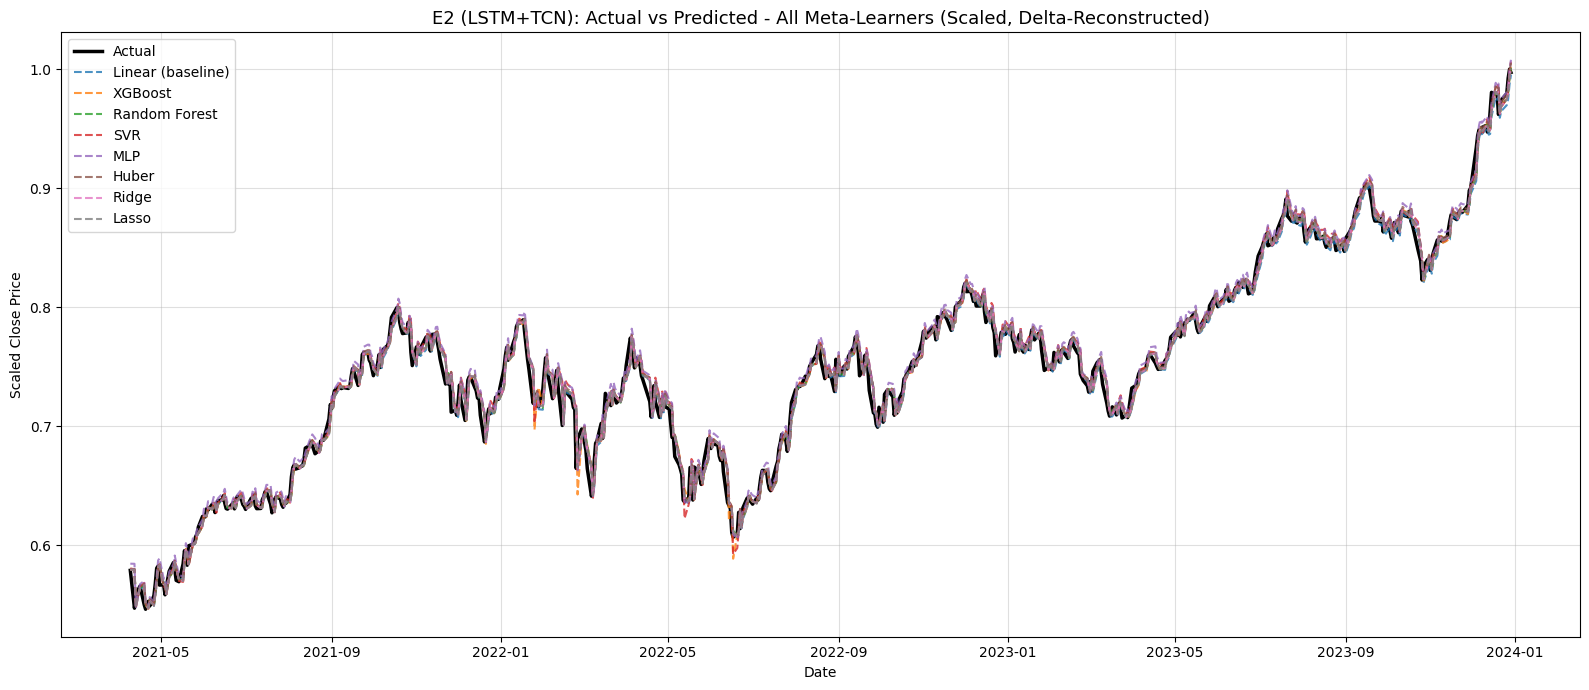

In [ ]:
# --- Prediction plot: all meta-learners on E2 (scaled, updated) ----------------------

# Prepare new pred variables for plotting (they should be defined in the previous cell)
# pred_huber = globals().get('pred_huber', None)
# pred_ridge = globals().get('pred_ridge', None)
# pred_lasso = globals().get('pred_lasso', None)

plt.figure(figsize=(16, 7))
plt.plot(test_dates, y_test,        label="Actual",            linewidth=2.5, color="black")
plt.plot(test_dates, pred_linear,   label="Linear (baseline)",  linestyle="--", alpha=0.8)
plt.plot(test_dates, pred_xgboost,  label="XGBoost",            linestyle="--", alpha=0.8)
plt.plot(test_dates, pred_randomforest, label="Random Forest",  linestyle="--", alpha=0.8)
plt.plot(test_dates, pred_svr,      label="SVR",                linestyle="--", alpha=0.8)
plt.plot(test_dates, pred_mlp,      label="MLP",                linestyle="--", alpha=0.8)

if 'pred_huber' in globals(): plt.plot(test_dates, pred_huber, label="Huber", linestyle="--", alpha=0.8)
if 'pred_ridge' in globals(): plt.plot(test_dates, pred_ridge, label="Ridge", linestyle="--", alpha=0.8)
if 'pred_lasso' in globals(): plt.plot(test_dates, pred_lasso, label="Lasso", linestyle="--", alpha=0.8)


plt.title("E2 (LSTM+TCN): Actual vs Predicted - All Meta-Learners (Scaled, Delta-Reconstructed)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Scaled Close Price")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

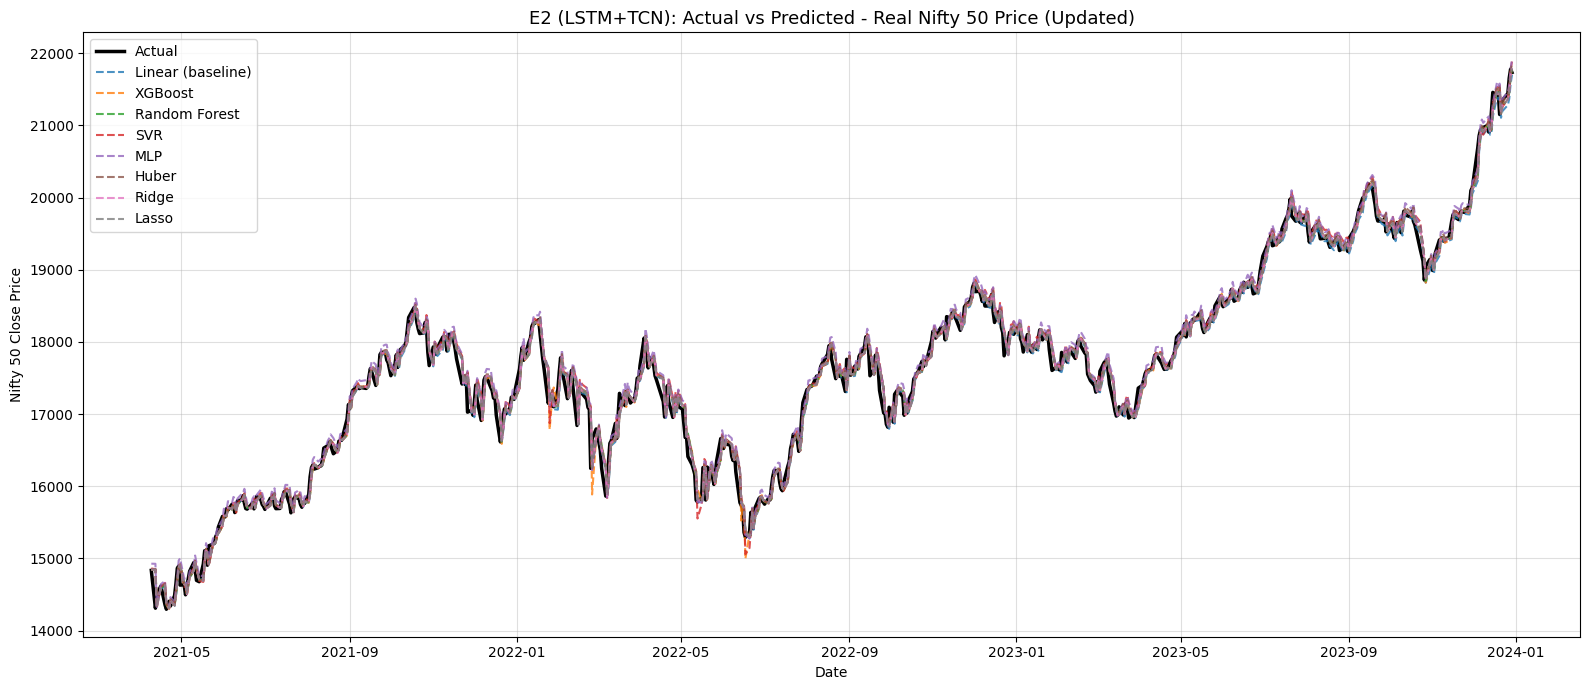

In [ ]:
# --- Convert predictions back to real Nifty price (updated) ---------------------------

price_huber = to_price(pred_huber) if 'pred_huber' in globals() else None
price_ridge = to_price(pred_ridge) if 'pred_ridge' in globals() else None
price_lasso = to_price(pred_lasso) if 'pred_lasso' in globals() else None

plt.figure(figsize=(16, 7))
plt.plot(test_dates, y_test_price,  label="Actual",            linewidth=2.5, color="black")
plt.plot(test_dates, price_linear,  label="Linear (baseline)", linestyle="--", alpha=0.8)
plt.plot(test_dates, price_xgb,     label="XGBoost",           linestyle="--", alpha=0.8)
plt.plot(test_dates, price_rf,      label="Random Forest",     linestyle="--", alpha=0.8)
plt.plot(test_dates, price_svr,     label="SVR",               linestyle="--", alpha=0.8)
plt.plot(test_dates, price_mlp,     label="MLP",               linestyle="--", alpha=0.8)

if price_huber is not None: plt.plot(test_dates, price_huber, label="Huber", linestyle="--", alpha=0.8)
if price_ridge is not None: plt.plot(test_dates, price_ridge, label="Ridge", linestyle="--", alpha=0.8)
if price_lasso is not None: plt.plot(test_dates, price_lasso, label="Lasso", linestyle="--", alpha=0.8)

plt.title("E2 (LSTM+TCN): Actual vs Predicted - Real Nifty 50 Price (Updated)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Nifty 50 Close Price")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Running 5-Fold CV on E2 (LSTM+TCN) meta-learner predictions (delta-space) with UPDATED meta-learners...

  Fold 1/5 ... [LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000053 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 864, number of used features: 2
[LightGBM] [Info] Start training from score 0.000349
done
  Fold 2/5 ... [LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000056 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 864, number of used features: 2
[LightGBM] [Info] Start training from score 0.000923
done
  Fold 3/5 ... [LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000053 seconds.
You can set `force_col_wise=true` to remove the overhead.
[L

,MSE (mean),RMSE (mean),R2 (mean),MAE (mean),MAPE (mean),RMSE (std),R2 (std)
Meta-Learner,,,,,,,
Linear,0.00009604,0.00978288,0.99741692,0.00705656,0.01416216,0.00058278,0.00044407
XGBoost,0.00009879,0.00992053,0.99736090,0.00711986,0.01436259,0.00061057,0.00034640
RandomForest,0.00009490,0.00972450,0.99745171,0.00701261,0.01406003,0.00057753,0.00041504
SVR,0.00011163,0.01052418,0.99704028,0.00723793,0.01472754,0.00093394,0.00040851
MLP,0.00010772,0.01036983,0.99713120,0.00744124,0.01518835,0.00042896,0.00013207
Huber,0.00009588,0.00976973,0.99741882,0.00702886,0.01411853,0.00065422,0.00048690
Ridge,0.00009526,0.00974270,0.99743801,0.00702884,0.01410564,0.00058688,0.00044279
Lasso,0.00009510,0.00973394,0.99744226,0.00702759,0.01410031,0.00059150,0.00044508
LightGBM,0.00009874,0.00992499,0.99734609,0.00718241,0.01441114,0.00048251,0.00040558


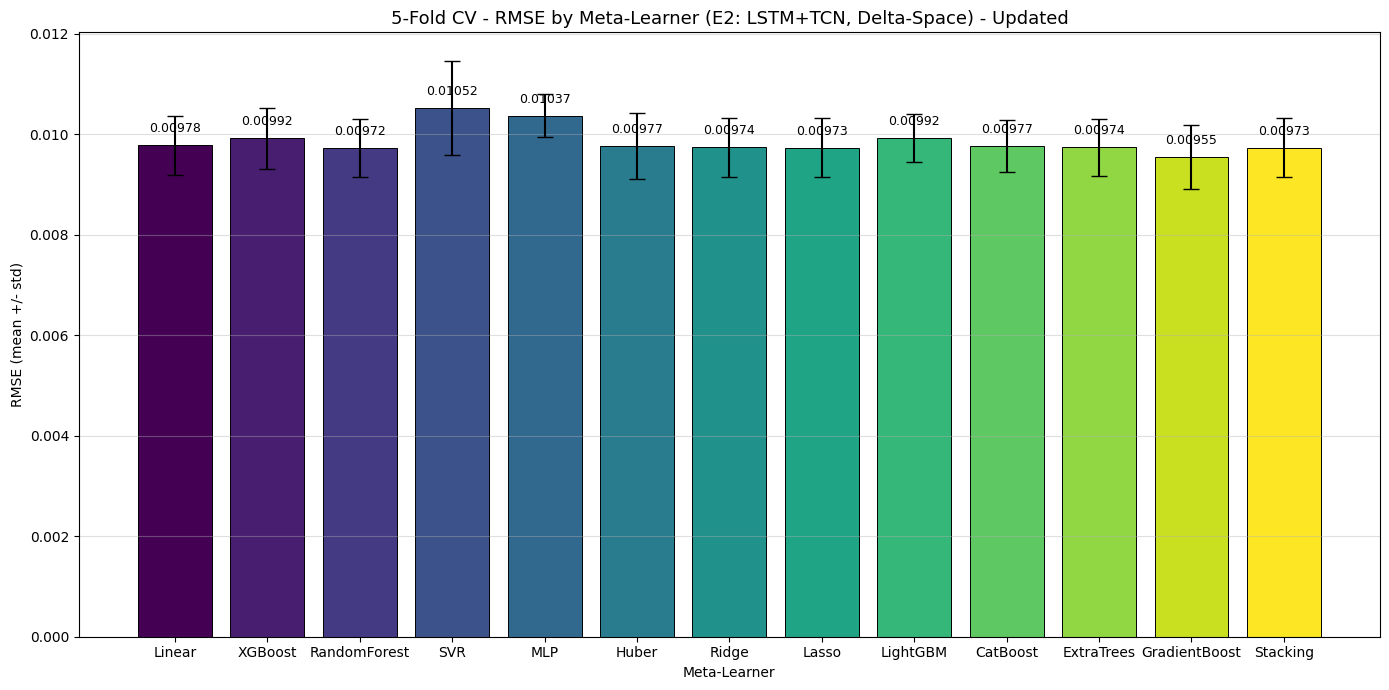


Running 5-Fold CV on E1 (LSTM+CNN) meta-learner predictions (delta-space) with UPDATED meta-learners...

  Fold 1/5 ... [LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 864, number of used features: 2
[LightGBM] [Info] Start training from score 0.000752
done
  Fold 2/5 ... [LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000049 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 864, number of used features: 2
[LightGBM] [Info] Start training from score 0.000568
done
  Fold 3/5 ... [LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000051 seconds.
You can set `force_col_wise=true` to remove the overhead.
[

,MSE (mean),RMSE (mean),R2 (mean),MAE (mean),MAPE (mean),RMSE (std),R2 (std)
Meta-Learner,,,,,,,
Linear,0.00009531,0.00975303,0.99746913,0.00701872,0.01411591,0.00043193,0.00024367
XGBoost,0.00010069,0.01001799,0.99732836,0.00713254,0.01440150,0.00057102,0.00030033
RandomForest,0.00009957,0.00996357,0.99735539,0.00709604,0.01438660,0.00054835,0.00030882
SVR,0.00011472,0.01066737,0.99696884,0.00731588,0.01533675,0.00096461,0.00044416
MLP,0.00010016,0.00999411,0.99734014,0.00720956,0.01456740,0.00052520,0.00030363
Huber,0.00009525,0.00975025,0.99747032,0.00700943,0.01409681,0.00043157,0.00024579
Ridge,0.00009474,0.00972415,0.99748337,0.00701384,0.01408892,0.00042620,0.00024888
Lasso,0.00009466,0.00971977,0.99748541,0.00701349,0.01408301,0.00042687,0.00025104
LightGBM,0.00010282,0.01012347,0.99727057,0.00725002,0.01465162,0.00058175,0.00031907


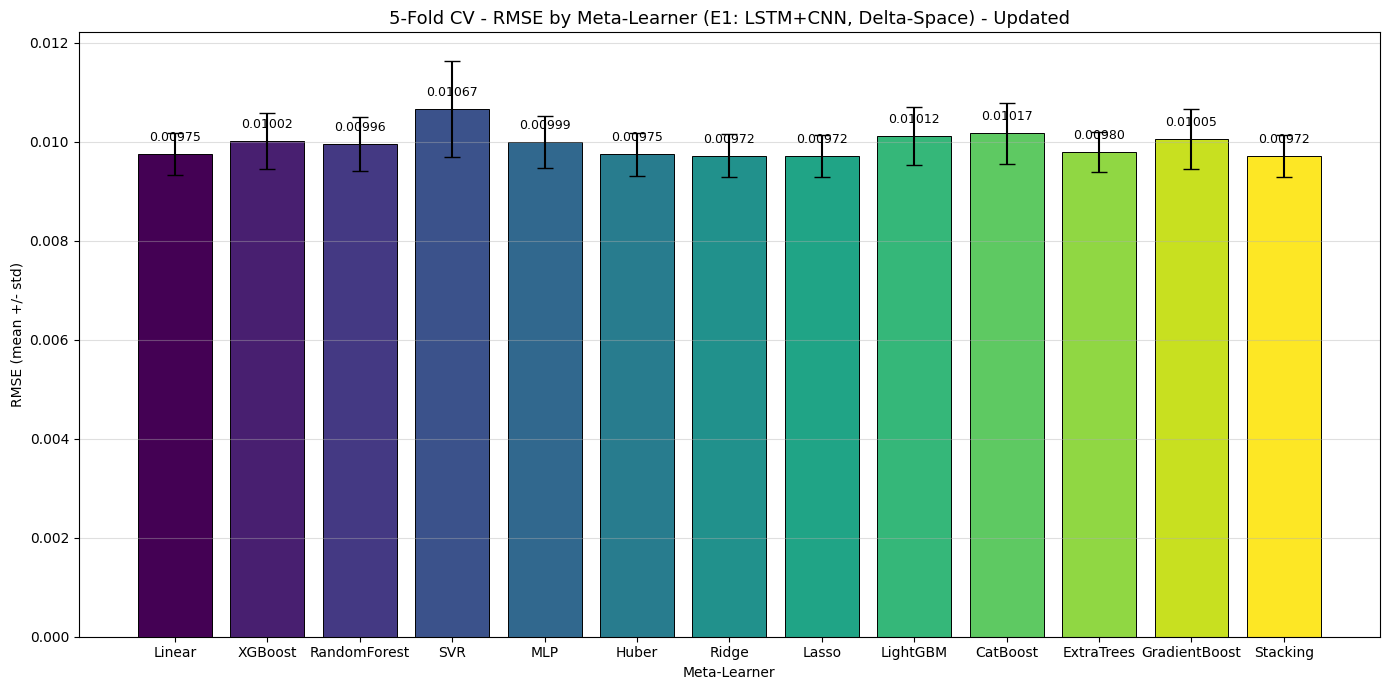

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import HuberRegressor, Ridge, Lasso
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, StackingRegressor
from lightgbm import LGBMRegressor # Assuming this is imported at the top, or include here if not
from catboost import CatBoostRegressor # Assuming this is imported at the top, or include here if not

# Redefine make_meta_learners to ensure all new models are included
def make_meta_learners():
    base_estimators = [
        ('linear', LinearRegression()),
        ('xgb', XGBRegressor(
            n_estimators=50, max_depth=1, learning_rate=0.05, random_state=SEED, verbosity=0)),
        ('rf', RandomForestRegressor(
            n_estimators=50, max_depth=2, min_samples_leaf=5, random_state=SEED, n_jobs=-1))
    ]

    return {
        "Linear":       LinearRegression(),
        "XGBoost":      XGBRegressor(
                            n_estimators=100,
                            max_depth=2,
                            learning_rate=0.05,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            reg_lambda=1.0,
                            random_state=SEED,
                            verbosity=0
                        ),
        "RandomForest": RandomForestRegressor(
                            n_estimators=100,
                            max_depth=3,
                            min_samples_leaf=5,
                            random_state=SEED,
                            n_jobs=-1
                        ),
        "SVR":          SVR(kernel="rbf", C=1.0, epsilon=0.001, gamma="scale"),
        "MLP":          MLPRegressor(
                            hidden_layer_sizes=(16,),
                            activation="relu",
                            alpha=0.01,
                            max_iter=2000,
                            random_state=SEED
                        ),
        "Huber":        HuberRegressor(epsilon=1.35, max_iter=500, alpha=0.0001),
        "Ridge":        Ridge(alpha=1.0, random_state=SEED),
        "Lasso":        Lasso(alpha=0.0001, random_state=SEED, max_iter=2000),
        "LightGBM":     LGBMRegressor(random_state=SEED, n_estimators=100, num_leaves=10, learning_rate=0.05),
        "CatBoost":     CatBoostRegressor(random_state=SEED, iterations=100, depth=5, learning_rate=0.1, verbose=0),
        "ExtraTrees":   ExtraTreesRegressor(
                            n_estimators=100, max_depth=3, min_samples_leaf=5, random_state=SEED, n_jobs=-1
                        ),
        "GradientBoost": GradientBoostingRegressor(
                            n_estimators=100, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=SEED
                        ),
        "Stacking":     StackingRegressor(
                            estimators=base_estimators,
                            final_estimator=Ridge(random_state=SEED),
                            cv=3,  # Using a small CV for stacking during meta-learner training
                            n_jobs=-1, verbose=0
                        )
    }

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True)

# === 5-FOLD CV FOR ENSEMBLE 2 (LSTM + TCN) ===
print("Running 5-Fold CV on E2 (LSTM+TCN) meta-learner predictions (delta-space) with UPDATED meta-learners...\n")

cv_results_e2_updated = {name: {"MSE":[], "RMSE":[], "R2":[], "MAE":[], "MAPE":[]} for name in make_meta_learners()}

fold_num = 1
for train_idx, test_idx in kf.split(meta_full_delta):
    print(f"  Fold {fold_num}/5 ...", end=" ")

    Xm_tr, Xm_te   = meta_full_delta[train_idx], meta_full_delta[test_idx]
    ydelta_tr      = y_full_delta[train_idx]
    prev_te        = prev_full[test_idx]
    ylevel_te      = y_full_level[test_idx]

    fold_learners = make_meta_learners()

    for learner_name, learner in fold_learners.items():
        learner.fit(Xm_tr, ydelta_tr)
        pred_delta = learner.predict(Xm_te)
        pred_level = prev_te + pred_delta

        m = calculate_metrics(ylevel_te, pred_level, "", verbose=False)
        for metric in ["MSE","RMSE","R2","MAE","MAPE"]:
            cv_results_e2_updated[learner_name][metric].append(m[metric])

    print("done")
    fold_num += 1

print("\nCross-validation for E2 with updated meta-learners complete.")

# Summary Table for E2
cv_rows_e2 = []
for learner_name, scores in cv_results_e2_updated.items():
    row = {"Meta-Learner": learner_name}
    for metric, vals in scores.items():
        row[f"{metric} (mean)"] = np.mean(vals)
        row[f"{metric} (std)"]  = np.std(vals)
    cv_rows_e2.append(row)

cv_df_e2 = pd.DataFrame(cv_rows_e2).set_index("Meta-Learner")

print("\n" + "="*60)
print("  5-FOLD CV SUMMARY (E2: LSTM+TCN) - Updated Meta-Learners")
print("="*60)
display(cv_df_e2[["MSE (mean)","RMSE (mean)","R2 (mean)","MAE (mean)","MAPE (mean)",
                       "RMSE (std)","R2 (std)"]])

# RMSE Bar Chart for E2
learner_names_e2 = list(cv_results_e2_updated.keys())
means_e2 = [np.mean(cv_results_e2_updated[n]["RMSE"]) for n in learner_names_e2]
stds_e2  = [np.std(cv_results_e2_updated[n]["RMSE"])  for n in learner_names_e2]

colors_e2 = plt.cm.get_cmap('viridis', len(learner_names_e2)).colors

plt.figure(figsize=(14, 7))
bars = plt.bar(learner_names_e2, means_e2, yerr=stds_e2, capsize=6,
               color=colors_e2, edgecolor="black", linewidth=0.7)

for bar, val in zip(bars, means_e2):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f"{val:.5f}", ha="center", va="bottom", fontsize=9)

plt.title("5-Fold CV - RMSE by Meta-Learner (E2: LSTM+TCN, Delta-Space) - Updated", fontsize=13)
plt.xlabel("Meta-Learner")
plt.ylabel("RMSE (mean +/- std)")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


# === 5-FOLD CV FOR ENSEMBLE 1 (LSTM + CNN) ===
print("\n" + "="*60)
print("Running 5-Fold CV on E1 (LSTM+CNN) meta-learner predictions (delta-space) with UPDATED meta-learners...\n")
print("="*60)

cv_results_e1_updated = {name: {"MSE":[], "RMSE":[], "R2":[], "MAE":[], "MAPE":[]} for name in make_meta_learners()}

fold_num = 1
for train_idx, test_idx in kf.split(meta_full_delta_e1):
    print(f"  Fold {fold_num}/5 ...", end=" ")

    Xm_tr, Xm_te   = meta_full_delta_e1[train_idx], meta_full_delta_e1[test_idx]
    ydelta_tr      = y_full_delta[train_idx]
    prev_te        = prev_full[test_idx]
    ylevel_te      = y_full_level[test_idx]

    fold_learners = make_meta_learners()

    for learner_name, learner in fold_learners.items():
        learner.fit(Xm_tr, ydelta_tr)
        pred_delta = learner.predict(Xm_te)
        pred_level = prev_te + pred_delta

        m = calculate_metrics(ylevel_te, pred_level, "", verbose=False)
        for metric in ["MSE","RMSE","R2","MAE","MAPE"]:
            cv_results_e1_updated[learner_name][metric].append(m[metric])

    print("done")
    fold_num += 1

print("\nCross-validation for E1 with updated meta-learners complete.")

# Summary Table for E1
cv_rows_e1 = []
for learner_name, scores in cv_results_e1_updated.items():
    row = {"Meta-Learner": learner_name}
    for metric, vals in scores.items():
        row[f"{metric} (mean)"] = np.mean(vals)
        row[f"{metric} (std)"]  = np.std(vals)
    cv_rows_e1.append(row)

cv_df_e1 = pd.DataFrame(cv_rows_e1).set_index("Meta-Learner")

print("\n" + "="*60)
print("  5-FOLD CV SUMMARY (E1: LSTM+CNN) - Updated Meta-Learners")
print("="*60)
display(cv_df_e1[["MSE (mean)","RMSE (mean)","R2 (mean)","MAE (mean)","MAPE (mean)",
                       "RMSE (std)","R2 (std)"]])

# RMSE Bar Chart for E1
learner_names_e1 = list(cv_results_e1_updated.keys())
means_e1 = [np.mean(cv_results_e1_updated[n]["RMSE"]) for n in learner_names_e1]
stds_e1  = [np.std(cv_results_e1_updated[n]["RMSE"])  for n in learner_names_e1]

colors_e1 = plt.cm.get_cmap('viridis', len(learner_names_e1)).colors

plt.figure(figsize=(14, 7))
bars = plt.bar(learner_names_e1, means_e1, yerr=stds_e1, capsize=6,
               color=colors_e1, edgecolor="black", linewidth=0.7)

for bar, val in zip(bars, means_e1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f"{val:.5f}", ha="center", va="bottom", fontsize=9)

plt.title("5-Fold CV - RMSE by Meta-Learner (E1: LSTM+CNN, Delta-Space) - Updated", fontsize=13)
plt.xlabel("Meta-Learner")
plt.ylabel("RMSE (mean +/- std)")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

Isolating code for Random Forest meta-learner (Ensemble 2: LSTM+TCN)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Random Forest E2 (LSTM+TCN) isolated Metrics:
----------------------------------------
MSE  : 0.00008239
RMSE : 0.00907699
R2   : 0.98899017
MAE  : 0.00689801
MAPE : 0.00943253


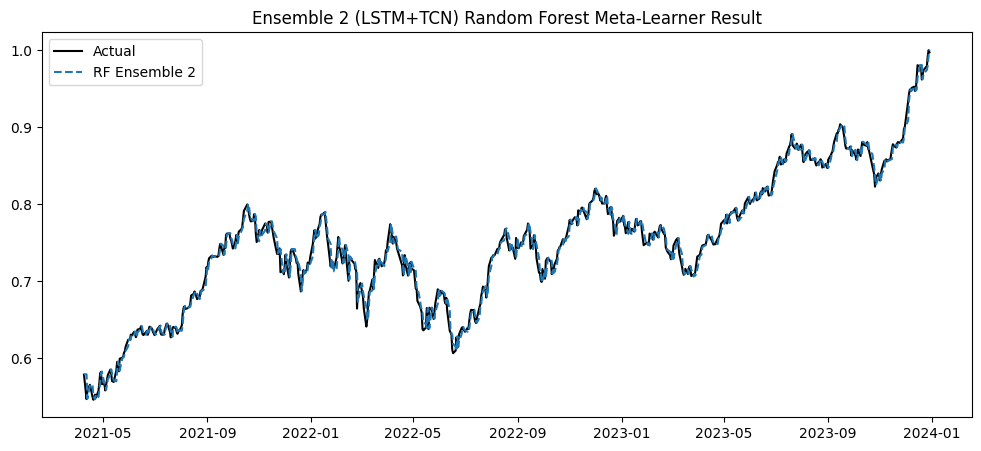

In [ ]:
# --- INSTALL DEPENDENCIES ---
!pip install -q yfinance catboost lightgbm xgboost

print('Isolating code for Random Forest meta-learner (Ensemble 2: LSTM+TCN)')

# --- IMPORTS ---
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import HuberRegressor, Ridge, Lasso
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- CONFIGURATION ---
SEED = 42
TICKER       = "^NSEI"
START_DATE   = "2013-01-01"
END_DATE     = "2024-01-01"
FEATURE_COLS = ["Open", "High", "Low", "Close"]
TARGET_COL   = "Close"
WINDOW_SIZE  = 10
TRAIN_RATIO  = 0.60
VAL_RATIO    = 0.15
TEST_RATIO   = 0.25
BATCH_SIZE    = 64
EPOCHS        = 5 # Reduced for quick isolated execution
LEARNING_RATE = 0.0001

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Data Processing ---
df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False)
if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
df = df[FEATURE_COLS].dropna()

def create_sequences(features, target, window_size):
    X, y, target_indices = [], [], []
    for i in range(window_size, len(features)):
        X.append(features[i - window_size:i])
        y.append(target[i])
        target_indices.append(i)
    return np.array(X), np.array(y), np.array(target_indices)

feature_scaler, target_scaler = MinMaxScaler(), MinMaxScaler()
features_scaled = feature_scaler.fit_transform(df[FEATURE_COLS])
target_scaled = target_scaler.fit_transform(df[[TARGET_COL]]).reshape(-1)

X, y, target_indices = create_sequences(features_scaled, target_scaled, WINDOW_SIZE)
n = len(df)
train_end, val_end = int(n * TRAIN_RATIO), int(n * (TRAIN_RATIO + VAL_RATIO))

train_mask, val_mask, test_mask = target_indices < train_end, (target_indices >= train_end) & (target_indices < val_end), target_indices >= val_end
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]
input_shape = (X_train.shape[1], X_train.shape[2])
test_dates = df.index[target_indices][test_mask]

# --- Model Builders ---
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, activation="tanh", input_shape=input_shape))
    model.add(Dropout(0.1))
    model.add(Dense(1))
    model.compile(optimizer=Adam(LEARNING_RATE), loss="mse")
    return model

def build_tcn_model(input_shape):
    model = Sequential()
    model.add(Conv1D(64, 3, padding="causal", dilation_rate=1, activation="relu", input_shape=input_shape))
    model.add(Dropout(0.1))
    model.add(Conv1D(64, 3, padding="causal", dilation_rate=2, activation="relu"))
    model.add(Dropout(0.1))
    model.add(Flatten())
    model.add(Dense(64, activation="relu"))
    model.add(Dense(1))
    model.compile(optimizer=Adam(LEARNING_RATE), loss="mse")
    return model

# Train Base Models
lstm_model = build_lstm_model(input_shape)
tcn_model = build_tcn_model(input_shape)

lstm_model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
tcn_model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

# Get Predictions
lstm_val_pred, lstm_test_pred = lstm_model.predict(X_val).reshape(-1), lstm_model.predict(X_test).reshape(-1)
tcn_val_pred, tcn_test_pred = tcn_model.predict(X_val).reshape(-1), tcn_model.predict(X_test).reshape(-1)

# Delta Space Transform
def to_deltas(pred, true):
    prev = np.concatenate([[true[0]], true[:-1]])
    return pred - prev, prev

l_v_d, v_prev = to_deltas(lstm_val_pred, y_val)
t_v_d, _ = to_deltas(tcn_val_pred, y_val)
y_v_d = y_val - v_prev

l_t_d, t_prev = to_deltas(lstm_test_pred, y_test)
t_t_d, _ = to_deltas(tcn_test_pred, y_test)

meta_train_e2 = np.column_stack([l_v_d, t_v_d])
meta_test_e2 = np.column_stack([l_t_d, t_t_d])

# Random Forest Meta-Learner
rf = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=SEED)
rf.fit(meta_train_e2, y_v_d)
pred_delta = rf.predict(meta_test_e2)
final_pred = t_prev + pred_delta

# Metrics Calculation
mse = mean_squared_error(y_test, final_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, final_pred)
mae = mean_absolute_error(y_test, final_pred)
mape = np.mean(np.abs((y_test - final_pred) / (y_test + 1e-8)))

print(f"\nRandom Forest E2 (LSTM+TCN) isolated Metrics:")
print(f"-" * 40)
print(f"MSE  : {mse:.8f}")
print(f"RMSE : {rmse:.8f}")
print(f"R2   : {r2:.8f}")
print(f"MAE  : {mae:.8f}")
print(f"MAPE : {mape:.8f}")

plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test, label='Actual', color='black')
plt.plot(test_dates, final_pred, label='RF Ensemble 2', linestyle='--')
plt.title('Ensemble 2 (LSTM+TCN) Random Forest Meta-Learner Result')
plt.legend(); plt.show()

In [ ]:
# --- EVALUATE ALL META-LEARNERS ON THE TRUE TEST SET FOR E1 (LSTM+CNN) ---

fresh_learners_e1 = make_meta_learners()

ensemble_name = "E1 (LSTM+CNN)"
meta_train, meta_test = meta_train_e1, meta_test_e1

print(f"\n{'='*70}")
print(f"  {ensemble_name} - TRUE TEST SET EVALUATION FOR ALL META-LEARNERS")
print(f"{'='*70}")

current_e1_test_results = []

for learner_name, learner in fresh_learners_e1.items():
    # 1. Train meta-learner on the validation-period deltas
    learner.fit(meta_train, y_val_delta)

    # 2. Predict deltas for the TEST period
    pred_delta_test = learner.predict(meta_test)

    # 3. Reconstruct price levels for the TEST period
    ensemble_pred_test = test_prev + pred_delta_test

    # 4. Explicitly tag this as the Test Set evaluation in the printout
    test_tag = f"{ensemble_name} | {learner_name} (TEST SET)"

    # This calls the notebook's built-in metric function on the test ground truth (y_test)
    m = calculate_metrics(y_test, ensemble_pred_test, test_tag)

    # Store data for the final summary dataframe
    m["Ensemble"] = ensemble_name
    m["Meta-Learner"] = learner_name
    current_e1_test_results.append(m)

    # Save test predictions to globals for plotting if needed
    globals()[f"pred_e1_{learner_name.lower()}_test"] = ensemble_pred_test

print(f"\n All meta-learners evaluated on the E1 TEST SET.")

# Display results in a clear summary table labeled specifically for the Test Set
import pandas as pd
df_e1_test_summary = pd.DataFrame(current_e1_test_results)
df_e1_test_summary = df_e1_test_summary[["Meta-Learner", "MSE", "RMSE", "R2", "MAE", "MAPE"]].sort_values("MSE")

print("\n" + "="*70)
print(f"  FINAL SUMMARY TABLE: {ensemble_name} PERFORMANCE ON TEST SET")
print("="*70)
display(df_e1_test_summary)


  E1 (LSTM+CNN) - TRUE TEST SET EVALUATION FOR ALL META-LEARNERS

E1 (LSTM+CNN) | Linear (TEST SET)
--------------------------------------------------
MSE  : 0.00008369
RMSE : 0.00914801
R2   : 0.98881719
MAE  : 0.00690721
MAPE : 0.00945431

E1 (LSTM+CNN) | XGBoost (TEST SET)
--------------------------------------------------
MSE  : 0.00008666
RMSE : 0.00930888
R2   : 0.98842045
MAE  : 0.00701903
MAPE : 0.00961911

E1 (LSTM+CNN) | RandomForest (TEST SET)
--------------------------------------------------
MSE  : 0.00008438
RMSE : 0.00918585
R2   : 0.98872450
MAE  : 0.00692587
MAPE : 0.00948257

E1 (LSTM+CNN) | SVR (TEST SET)
--------------------------------------------------
MSE  : 0.00022548
RMSE : 0.01501593
R2   : 0.96986984
MAE  : 0.01110562
MAPE : 0.01456791

E1 (LSTM+CNN) | MLP (TEST SET)
--------------------------------------------------
MSE  : 0.00010387
RMSE : 0.01019172
R2   : 0.98611993
MAE  : 0.00781884
MAPE : 0.01069047

E1 (LSTM+CNN) | Huber (TEST SET)
-------------------

,Meta-Learner,MSE,RMSE,R2,MAE,MAPE
6,Ridge,0.00008302,0.00911165,0.98890593,0.00690298,0.00943759
12,Stacking,0.00008303,0.00911223,0.98890452,0.00690475,0.00943954
7,Lasso,0.00008303,0.00911231,0.98890433,0.00690477,0.00943957
0,Linear,0.00008369,0.00914801,0.98881719,0.00690721,0.00945431
10,ExtraTrees,0.00008370,0.00914898,0.98881483,0.00690848,0.00945072
2,RandomForest,0.00008438,0.00918585,0.98872450,0.00692587,0.00948257
5,Huber,0.00008505,0.00922228,0.98863489,0.00695759,0.00952513
1,XGBoost,0.00008666,0.00930888,0.98842045,0.00701903,0.00961911
11,GradientBoost,0.00008695,0.00932447,0.98838163,0.00699245,0.00959104
9,CatBoost,0.00008986,0.00947959,0.98799186,0.00713991,0.00977750



######################################################################
#  SCALER: MinMax
######################################################################
  [MinMax] E1 (LSTM+CNN) | Linear         RMSE=0.009148  R2=0.988817
  [MinMax] E1 (LSTM+CNN) | XGBoost        RMSE=0.009309  R2=0.988420
  [MinMax] E1 (LSTM+CNN) | RandomForest   RMSE=0.009186  R2=0.988725
  [MinMax] E1 (LSTM+CNN) | SVR            RMSE=0.015016  R2=0.969870
  [MinMax] E1 (LSTM+CNN) | MLP            RMSE=0.010192  R2=0.986120
  [MinMax] E1 (LSTM+CNN) | Huber          RMSE=0.009222  R2=0.988635
  [MinMax] E1 (LSTM+CNN) | Ridge          RMSE=0.009112  R2=0.988906
  [MinMax] E1 (LSTM+CNN) | Lasso          RMSE=0.009112  R2=0.988904
  [MinMax] E1 (LSTM+CNN) | LightGBM       RMSE=0.009634  R2=0.987598
  [MinMax] E1 (LSTM+CNN) | CatBoost       RMSE=0.009480  R2=0.987992
  [MinMax] E1 (LSTM+CNN) | ExtraTrees     RMSE=0.009149  R2=0.988815
  [MinMax] E1 (LSTM+CNN) | GradientBoost  RMSE=0.009324  R2=0.988382
  [MinMax] 

,Scaler,Ensemble,Meta-Learner,MSE,RMSE,R2,MAE,MAPE
0,MinMax,E1 (LSTM+CNN),CatBoost,0.00008986,0.00947959,0.98799186,0.00713991,0.00977750
1,Robust,E1 (LSTM+CNN),CatBoost,0.00051583,0.02271197,0.98850155,0.01718085,0.01724280
2,Standard,E1 (LSTM+CNN),CatBoost,0.00149300,0.03863936,0.98732309,0.02954949,0.02105041
3,MinMax,E1 (LSTM+CNN),ExtraTrees,0.00008370,0.00914898,0.98881483,0.00690848,0.00945072
4,Robust,E1 (LSTM+CNN),ExtraTrees,0.00049829,0.02232249,0.98889254,0.01695203,0.01692023
...,...,...,...,...,...,...,...,...
82,Robust,Individual,LSTM,0.07703122,0.27754498,-0.71710278,0.25616018,0.23080833
83,Standard,Individual,LSTM,0.54315129,0.73698798,-3.61183926,0.69201741,0.44257085
84,MinMax,Individual,TCN,0.00128634,0.03586557,0.82810927,0.03111715,0.04105301
85,Robust,Individual,TCN,0.00229806,0.04793810,0.94877391,0.04068860,0.03851965



  BEST (Ensemble, Meta-Learner) PER SCALER


,Scaler,Ensemble,Meta-Learner,RMSE,R2,MAE,MAPE
0,MinMax,E2 (LSTM+TCN),RandomForest,0.00905968,0.98903213,0.00688127,0.00941003
1,Robust,E2 (LSTM+TCN),RandomForest,0.02220321,0.98901093,0.01686436,0.01682639
2,Standard,E2 (LSTM+TCN),Ridge,0.03614283,0.98890831,0.02739508,0.01957451


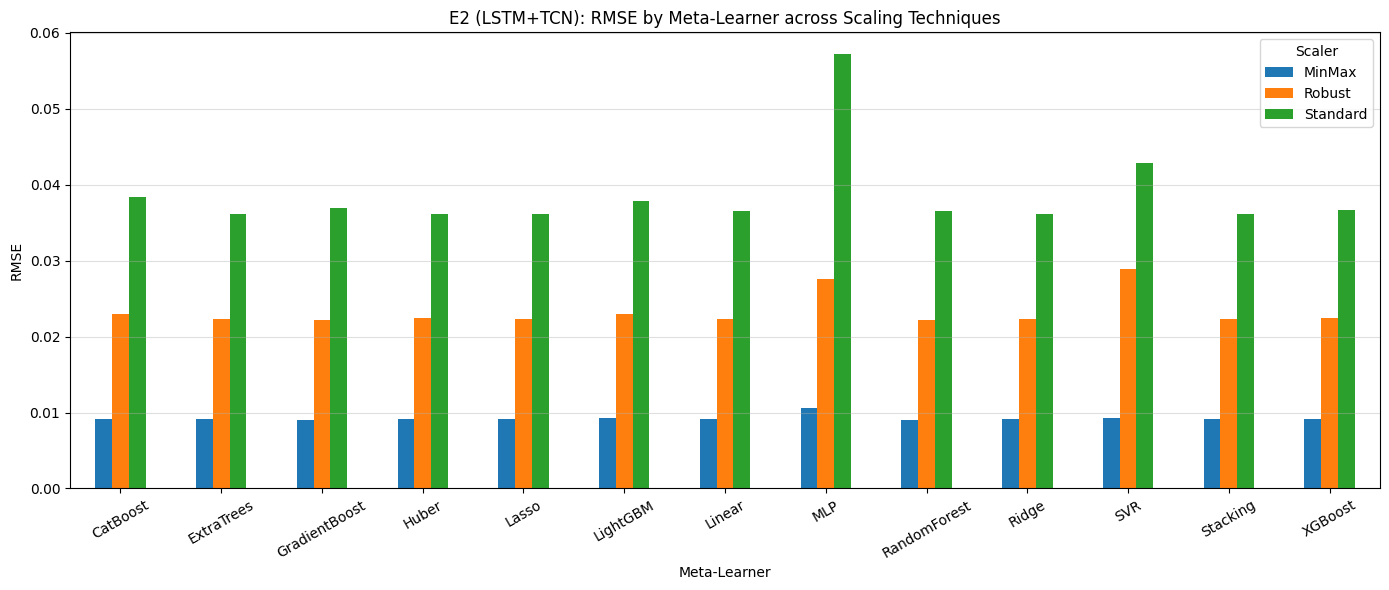

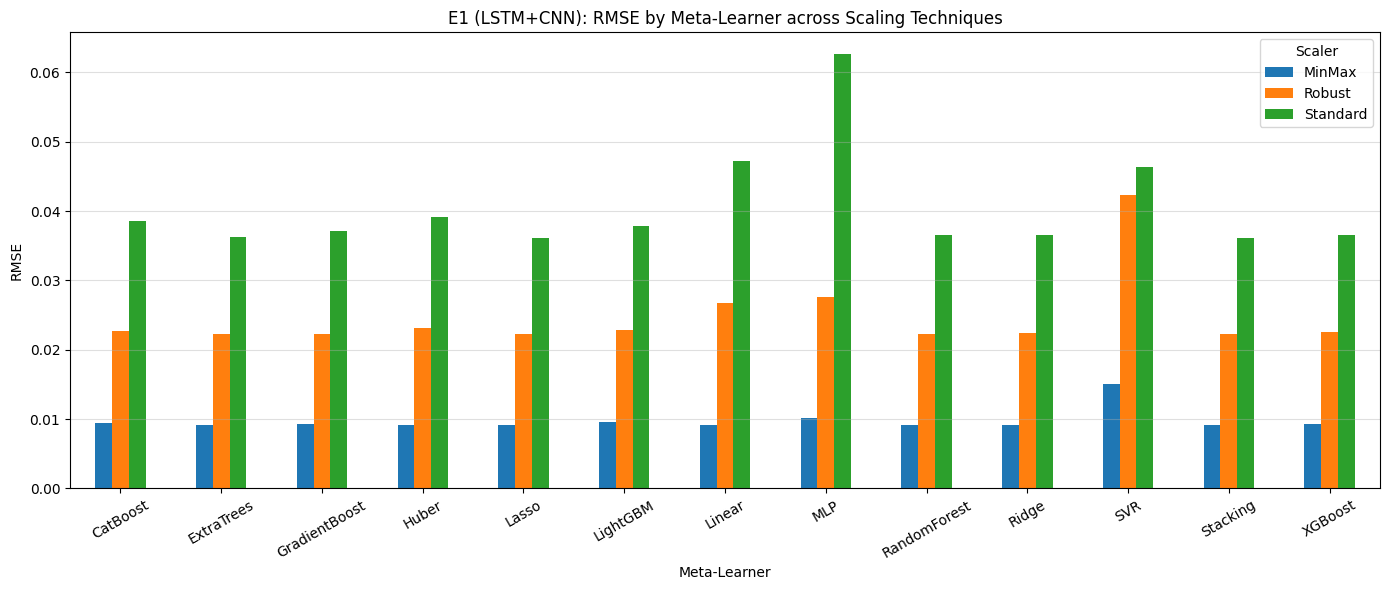

In [ ]:
# =====================================================================
# SCALER COMPARISON: MinMax vs Standard vs Robust
# Same architecture as original notebook (LSTM/CNN/TCN base models,
# delta-space meta-learner training, 13 meta-learner variants, E1/E2)
# =====================================================================

import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, HuberRegressor, Ridge, Lasso
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, StackingRegressor)
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------
# CONFIG (identical to original)
# ---------------------------------------------------------------------
SEED = 42
TICKER, START_DATE, END_DATE = "^NSEI", "2013-01-01", "2024-01-01"
FEATURE_COLS, TARGET_COL, WINDOW_SIZE = ["Open", "High", "Low", "Close"], "Close", 10
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.60, 0.15, 0.25
BATCH_SIZE, EPOCHS, LEARNING_RATE, PATIENCE = 64, 100, 0.0001, 10

def set_seed():
    os.environ["PYTHONHASHSEED"] = str(SEED)
    random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

set_seed()

# ---------------------------------------------------------------------
# DATA (downloaded ONCE — scaling is the only thing that changes per run)
# ---------------------------------------------------------------------
df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df[FEATURE_COLS].dropna()

def create_sequences(features, target, window_size):
    X, y, target_indices = [], [], []
    for i in range(window_size, len(features)):
        X.append(features[i - window_size:i])
        y.append(target[i])
        target_indices.append(i)
    return np.array(X), np.array(y), np.array(target_indices)

def calculate_metrics(y_true, y_pred):
    y_true, y_pred = np.array(y_true).reshape(-1), np.array(y_pred).reshape(-1)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MSE": mse, "RMSE": np.sqrt(mse), "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8)))
    }

def to_deltas(base_pred, y_true):
    prev_actual = np.concatenate([[y_true[0]], y_true[:-1]])
    return base_pred - prev_actual, prev_actual

# ---------------------------------------------------------------------
# BASE MODEL ARCHITECTURES (unchanged)
# ---------------------------------------------------------------------
def build_lstm_model(input_shape):
    m = Sequential(name="LSTM_Base_Model")
    m.add(LSTM(units=64, activation="tanh", input_shape=input_shape))
    m.add(Dropout(0.1)); m.add(Dense(1))
    m.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return m

def build_cnn_model(input_shape):
    m = Sequential(name="CNN_Base_Model")
    m.add(Conv1D(filters=64, kernel_size=3, activation="relu", input_shape=input_shape))
    m.add(MaxPooling1D(pool_size=2)); m.add(Dropout(0.2)); m.add(Flatten())
    m.add(Dense(64, activation="relu")); m.add(Dense(1))
    m.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return m

def build_tcn_model(input_shape):
    m = Sequential(name="TCN_Base_Model")
    m.add(Conv1D(filters=64, kernel_size=3, padding="causal", dilation_rate=1,
                 activation="relu", input_shape=input_shape))
    m.add(Dropout(0.1))
    m.add(Conv1D(filters=64, kernel_size=3, padding="causal", dilation_rate=2, activation="relu"))
    m.add(Dropout(0.1)); m.add(Flatten())
    m.add(Dense(64, activation="relu")); m.add(Dense(1))
    m.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return m

# ---------------------------------------------------------------------
# META-LEARNERS (unchanged — all 13)
# ---------------------------------------------------------------------
def make_meta_learners():
    base_estimators = [
        ('linear', LinearRegression()),
        ('xgb', XGBRegressor(n_estimators=50, max_depth=1, learning_rate=0.05,
                              random_state=SEED, verbosity=0)),
        ('rf', RandomForestRegressor(n_estimators=50, max_depth=2, min_samples_leaf=5,
                                      random_state=SEED, n_jobs=-1))
    ]
    return {
        "Linear":        LinearRegression(),
        "XGBoost":       XGBRegressor(n_estimators=100, max_depth=2, learning_rate=0.05,
                                       subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                                       random_state=SEED, verbosity=0),
        "RandomForest":  RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=5,
                                                random_state=SEED, n_jobs=-1),
        "SVR":           SVR(kernel="rbf", C=1.0, epsilon=0.001, gamma="scale"),
        "MLP":           MLPRegressor(hidden_layer_sizes=(16,), activation="relu",
                                       alpha=0.01, max_iter=2000, random_state=SEED),
        "Huber":         HuberRegressor(epsilon=1.35, max_iter=500, alpha=0.0001),
        "Ridge":         Ridge(alpha=1.0, random_state=SEED),
        "Lasso":         Lasso(alpha=0.0001, random_state=SEED, max_iter=2000),
        "LightGBM":      LGBMRegressor(random_state=SEED, n_estimators=100, num_leaves=10,
                                        learning_rate=0.05, verbose=-1),
        "CatBoost":      CatBoostRegressor(random_state=SEED, iterations=100, depth=5,
                                            learning_rate=0.1, verbose=0),
        "ExtraTrees":    ExtraTreesRegressor(n_estimators=100, max_depth=3, min_samples_leaf=5,
                                              random_state=SEED, n_jobs=-1),
        "GradientBoost": GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05,
                                                    subsample=0.8, random_state=SEED),
        "Stacking":      StackingRegressor(estimators=base_estimators,
                                            final_estimator=Ridge(random_state=SEED),
                                            cv=3, n_jobs=-1, verbose=0),
    }

# ---------------------------------------------------------------------
# SCALERS TO COMPARE
# ---------------------------------------------------------------------
SCALERS = {
    "MinMax":   (MinMaxScaler, MinMaxScaler),
    "Standard": (StandardScaler, StandardScaler),
    "Robust":   (RobustScaler, RobustScaler),
}

all_scaler_results = []

for scaler_name, (feat_scaler_cls, tgt_scaler_cls) in SCALERS.items():
    print(f"\n{'#'*70}\n#  SCALER: {scaler_name}\n{'#'*70}")
    set_seed()

    # --- Scale data with the current scaler --------------------------
    n = len(df)
    train_end = int(n * TRAIN_RATIO)
    val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

    feature_scaler = feat_scaler_cls()
    target_scaler  = tgt_scaler_cls()

    features_scaled = feature_scaler.fit_transform(df[FEATURE_COLS])
    target_scaled    = target_scaler.fit_transform(df[[TARGET_COL]]).reshape(-1)

    X, y, target_indices = create_sequences(features_scaled, target_scaled, WINDOW_SIZE)

    train_mask = target_indices < train_end
    val_mask   = (target_indices >= train_end) & (target_indices < val_end)
    test_mask  = target_indices >= val_end

    X_train, y_train = X[train_mask], y[train_mask]
    X_val,   y_val   = X[val_mask],   y[val_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]
    input_shape = (X_train.shape[1], X_train.shape[2])

    # --- Train base models -------------------------------------------
    tf.keras.backend.clear_session()

    lstm_model = build_lstm_model(input_shape)
    lstm_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                   epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=False, verbose=0,
                   callbacks=[EarlyStopping(monitor="val_loss", patience=15, min_delta=1e-6,
                                            restore_best_weights=True, start_from_epoch=20)])

    cnn_model = build_cnn_model(input_shape)
    cnn_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                  epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=False, verbose=0,
                  callbacks=[EarlyStopping(monitor="val_loss", patience=15, min_delta=1e-6,
                                           restore_best_weights=True, start_from_epoch=20)])

    tcn_model = build_tcn_model(input_shape)
    tcn_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                  epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=False, verbose=0,
                  callbacks=[EarlyStopping(monitor="val_loss", patience=10, min_delta=1e-6,
                                           restore_best_weights=True)])

    lstm_val_pred,  lstm_test_pred  = lstm_model.predict(X_val, verbose=0).reshape(-1),  lstm_model.predict(X_test, verbose=0).reshape(-1)
    cnn_val_pred,   cnn_test_pred   = cnn_model.predict(X_val, verbose=0).reshape(-1),   cnn_model.predict(X_test, verbose=0).reshape(-1)
    tcn_val_pred,   tcn_test_pred   = tcn_model.predict(X_val, verbose=0).reshape(-1),   tcn_model.predict(X_test, verbose=0).reshape(-1)

    base_metrics = {
        "LSTM": calculate_metrics(y_test, lstm_test_pred),
        "CNN":  calculate_metrics(y_test, cnn_test_pred),
        "TCN":  calculate_metrics(y_test, tcn_test_pred),
    }
    for base_name, m in base_metrics.items():
        row = {"Scaler": scaler_name, "Ensemble": "Individual", "Meta-Learner": base_name}
        row.update(m)
        all_scaler_results.append(row)

    # --- Delta-space meta-features (unchanged logic) -----------------
    lstm_val_delta, val_prev = to_deltas(lstm_val_pred, y_val)
    cnn_val_delta,  _        = to_deltas(cnn_val_pred,  y_val)
    tcn_val_delta,  _        = to_deltas(tcn_val_pred,  y_val)
    y_val_delta               = y_val - val_prev

    lstm_test_delta, test_prev = to_deltas(lstm_test_pred, y_test)
    cnn_test_delta,  _         = to_deltas(cnn_test_pred,  y_test)
    tcn_test_delta,  _         = to_deltas(tcn_test_pred,  y_test)

    meta_train_e1 = np.column_stack([lstm_val_delta,  cnn_val_delta])
    meta_test_e1  = np.column_stack([lstm_test_delta, cnn_test_delta])
    meta_train_e2 = np.column_stack([lstm_val_delta,  tcn_val_delta])
    meta_test_e2  = np.column_stack([lstm_test_delta, tcn_test_delta])

    # --- Train & evaluate all 13 meta-learners for E1 and E2 ----------
    for ensemble_name, (meta_train, meta_test) in [
        ("E1 (LSTM+CNN)", (meta_train_e1, meta_test_e1)),
        ("E2 (LSTM+TCN)", (meta_train_e2, meta_test_e2)),
    ]:
        learners = make_meta_learners()
        for learner_name, learner in learners.items():
            learner.fit(meta_train, y_val_delta)
            pred_delta = learner.predict(meta_test)
            ensemble_pred = test_prev + pred_delta
            m = calculate_metrics(y_test, ensemble_pred)
            row = {"Scaler": scaler_name, "Ensemble": ensemble_name, "Meta-Learner": learner_name}
            row.update(m)
            all_scaler_results.append(row)
            print(f"  [{scaler_name}] {ensemble_name} | {learner_name:14s} RMSE={m['RMSE']:.6f}  R2={m['R2']:.6f}")

# =====================================================================
# FINAL COMPARISON TABLE
# =====================================================================
results_df = pd.DataFrame(all_scaler_results)[
    ["Scaler", "Ensemble", "Meta-Learner", "MSE", "RMSE", "R2", "MAE", "MAPE"]
].sort_values(["Ensemble", "Meta-Learner", "Scaler"]).reset_index(drop=True)

pd.set_option("display.float_format", "{:.8f}".format)
print("\n" + "="*90)
print("  FULL RESULTS: All Scalers x All Ensembles x All Meta-Learners")
print("="*90)
display(results_df)

# --- Best combo per scaler (by RMSE, ensembles only) ------------------
best_per_scaler = (
    results_df[results_df["Ensemble"] != "Individual"]
    .sort_values("RMSE")
    .groupby("Scaler")
    .first()
    .reset_index()
)
print("\n" + "="*90)
print("  BEST (Ensemble, Meta-Learner) PER SCALER")
print("="*90)
display(best_per_scaler[["Scaler", "Ensemble", "Meta-Learner", "RMSE", "R2", "MAE", "MAPE"]])

# --- Grouped bar chart: RMSE per meta-learner, grouped by scaler (E2) --
e2_df = results_df[results_df["Ensemble"] == "E2 (LSTM+TCN)"]
pivot = e2_df.pivot(index="Meta-Learner", columns="Scaler", values="RMSE")

pivot.plot(kind="bar", figsize=(14, 6))
plt.title("E2 (LSTM+TCN): RMSE by Meta-Learner across Scaling Techniques")
plt.ylabel("RMSE"); plt.xlabel("Meta-Learner")
plt.xticks(rotation=30); plt.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

# --- Same for E1 --------------------------------------------------------
e1_df = results_df[results_df["Ensemble"] == "E1 (LSTM+CNN)"]
pivot_e1 = e1_df.pivot(index="Meta-Learner", columns="Scaler", values="RMSE")

pivot_e1.plot(kind="bar", figsize=(14, 6))
plt.title("E1 (LSTM+CNN): RMSE by Meta-Learner across Scaling Techniques")
plt.ylabel("RMSE"); plt.xlabel("Meta-Learner")
plt.xticks(rotation=30); plt.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

In [ ]:
print("\n" + "="*90)
print("  FILTERED RESULTS: MinMax Scaler, E2 (LSTM+TCN) Ensemble")
print("="*90)

# Example of filtering the results_df
# You can modify these filters to explore different combinations
filtered_results_df = results_df[
    (results_df["Scaler"] == "MinMax") &
    (results_df["Ensemble"] == "E2 (LSTM+TCN)")
].sort_values("RMSE").reset_index(drop=True)

display(filtered_results_df)


  FILTERED RESULTS: MinMax Scaler, E2 (LSTM+TCN) Ensemble


,Scaler,Ensemble,Meta-Learner,MSE,RMSE,R2,MAE,MAPE
0,MinMax,E2 (LSTM+TCN),RandomForest,0.00008208,0.00905968,0.98903213,0.00688127,0.00941003
1,MinMax,E2 (LSTM+TCN),GradientBoost,0.00008225,0.00906930,0.98900882,0.00689996,0.00945164
2,MinMax,E2 (LSTM+TCN),XGBoost,0.00008280,0.00909919,0.98893626,0.00693620,0.00949942
3,MinMax,E2 (LSTM+TCN),ExtraTrees,0.00008298,0.00910933,0.98891156,0.00689248,0.00943098
4,MinMax,E2 (LSTM+TCN),Ridge,0.00008301,0.00911124,0.98890692,0.00689995,0.00943457
5,MinMax,E2 (LSTM+TCN),Lasso,0.00008303,0.00911231,0.98890433,0.00690477,0.00943957
6,MinMax,E2 (LSTM+TCN),Stacking,0.00008303,0.00911234,0.98890425,0.00690475,0.00943956
7,MinMax,E2 (LSTM+TCN),CatBoost,0.00008304,0.00911263,0.98890353,0.00694353,0.00950476
8,MinMax,E2 (LSTM+TCN),Linear,0.00008350,0.00913805,0.98884154,0.00692554,0.00946628
9,MinMax,E2 (LSTM+TCN),Huber,0.00008378,0.00915296,0.98880510,0.00689145,0.00943473


In [ ]:
print("\n" + "="*90)
print("  FILTERED RESULTS: Standard Scaler")
print("="*90)

filtered_results_df = results_df[
    (results_df["Scaler"] == "Standard")
].sort_values("RMSE").reset_index(drop=True)

display(filtered_results_df)


  FILTERED RESULTS: Standard Scaler


,Scaler,Ensemble,Meta-Learner,MSE,RMSE,R2,MAE,MAPE
0,Standard,E2 (LSTM+TCN),Ridge,0.00130630,0.03614283,0.98890831,0.02739508,0.01957451
1,Standard,E1 (LSTM+CNN),Stacking,0.00130674,0.03614891,0.98890458,0.02739293,0.01957805
2,Standard,E2 (LSTM+TCN),Lasso,0.00130677,0.03614932,0.98890433,0.02739183,0.01957865
3,Standard,E2 (LSTM+TCN),Stacking,0.00130678,0.03614944,0.98890425,0.02739057,0.01957852
4,Standard,E1 (LSTM+CNN),Lasso,0.00130682,0.03615000,0.98890391,0.02739598,0.01958017
5,Standard,E2 (LSTM+TCN),Huber,0.00130730,0.03615657,0.98889988,0.02737686,0.01957829
6,Standard,E2 (LSTM+TCN),ExtraTrees,0.00130970,0.03618971,0.98887952,0.02742695,0.01957817
7,Standard,E1 (LSTM+CNN),ExtraTrees,0.00131800,0.03630422,0.98880903,0.02754424,0.01963549
8,Standard,E2 (LSTM+TCN),RandomForest,0.00133313,0.03651203,0.98868055,0.02781869,0.01977614
9,Standard,E1 (LSTM+CNN),Ridge,0.00133391,0.03652267,0.98867395,0.02755724,0.01973611


In [ ]:
print("\n" + "="*90)
print("  FILTERED RESULTS: Robust Scaler")
print("="*90)

filtered_results_df = results_df[
    (results_df["Scaler"] == "Robust")
].sort_values("RMSE").reset_index(drop=True)

display(filtered_results_df)


  FILTERED RESULTS: Robust Scaler


,Scaler,Ensemble,Meta-Learner,MSE,RMSE,R2,MAE,MAPE
0,Robust,E2 (LSTM+TCN),RandomForest,0.00049298,0.02220321,0.98901093,0.01686436,0.01682639
1,Robust,E1 (LSTM+CNN),GradientBoost,0.00049461,0.02223985,0.98897463,0.01682594,0.01684741
2,Robust,E2 (LSTM+TCN),GradientBoost,0.00049465,0.02224063,0.98897386,0.01693004,0.01687808
3,Robust,E1 (LSTM+CNN),Lasso,0.00049776,0.02231064,0.98890433,0.01690569,0.01689029
4,Robust,E2 (LSTM+TCN),Lasso,0.00049776,0.02231064,0.98890433,0.01690569,0.01689029
5,Robust,E2 (LSTM+TCN),Stacking,0.00049780,0.02231147,0.98890351,0.01690588,0.01689055
6,Robust,E1 (LSTM+CNN),Stacking,0.00049781,0.02231157,0.98890341,0.01690602,0.01689056
7,Robust,E1 (LSTM+CNN),RandomForest,0.00049798,0.02231549,0.98889951,0.01701542,0.01695492
8,Robust,E2 (LSTM+TCN),ExtraTrees,0.00049807,0.02231755,0.98889745,0.01691949,0.01689891
9,Robust,E1 (LSTM+CNN),ExtraTrees,0.00049829,0.02232249,0.98889254,0.01695203,0.01692023
